In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import h5py
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom
from scipy import interpolate

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

2026-03-08 20:22:21.349865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773001341.523348      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773001341.575784      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773001342.021939      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773001342.021980      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773001342.021983      25 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPUs Available: 2


In [2]:
def load_paired_reynolds_multi_3channel(file_paths, lr_dim, hr_dim):
    """
    Loads data from multiple HDF5 files and stacks u, v, p as 3 channels.
    Data is kept on its native physical grid — NO aspect-ratio remapping.
    Physical domain sizes (lx, ly) are returned so coordinate channels
    [x̄, ȳ] can be generated externally to encode geometry.

    Returns:
        x_lr:             (N, lr_dim, lr_dim, 3) - low resolution fields  [u, v, p]
        x_hr:             (N, hr_dim, hr_dim, 3) - high resolution fields [u, v, p]
        reynolds_numbers: (N,)
        bc_types:         (N,)
        lx_arr:           (N,) - physical domain length in x
        ly_arr:           (N,) - physical domain length in y
    """
    xs_lr_all, xs_hr_all, used_res_all, bc_types_all = [], [], [], []
    lx_all, ly_all = [], []
    
    for file_path in file_paths:
        print(f"\n📂 Loading from: {file_path}")
        
        try:
            with h5py.File(file_path, 'r') as f:
                all_keys = list(f.keys())
                if not all_keys: 
                    print(f"⚠️  File is empty, skipping.")
                    continue
                
                re_numbers_in_file = sorted(list(set(int(k.split('_')[0][2:]) for k in all_keys if k.startswith("Re"))))
                print(f"   Found Reynolds numbers: {re_numbers_in_file}")
                
                # Detect BC type from first group
                first_group = f[all_keys[0]]
                bc_type = first_group.attrs.get('bc_type', 'unknown')
                print(f"   BC Type: {bc_type}")
                
                for Re in re_numbers_in_file:
                    g_lr = f"Re{Re}_mesh{lr_dim}x{lr_dim}"
                    g_hr = f"Re{Re}_mesh{hr_dim}x{hr_dim}"
                    
                    if g_lr in all_keys and g_hr in all_keys:
                        if all(comp in f[g_lr] and comp in f[g_hr] for comp in ['u', 'v', 'p']):
                            # Load raw data
                            lr_u_raw = f[g_lr]['u'][()].astype(np.float32)
                            lr_v_raw = f[g_lr]['v'][()].astype(np.float32)
                            lr_p_raw = f[g_lr]['p'][()].astype(np.float32)
                            
                            hr_u_raw = f[g_hr]['u'][()].astype(np.float32)
                            hr_v_raw = f[g_hr]['v'][()].astype(np.float32)
                            hr_p_raw = f[g_hr]['p'][()].astype(np.float32)
                            
                            # Get physical domain dimensions (needed for coord channels)
                            lx_lr = float(f[g_lr].attrs.get('lx', 1.0))
                            ly_lr = float(f[g_lr].attrs.get('ly', 1.0))
                            lx_hr = float(f[g_hr].attrs.get('lx', 1.0))
                            ly_hr = float(f[g_hr].attrs.get('ly', 1.0))
                            
                            if len(xs_lr_all) == 0:
                                print(f"\n   🔍 DEBUG - First sample:")
                                print(f"      LR: {lr_dim}×{lr_dim}, domain: {lx_lr}×{ly_lr} (aspect: {lx_lr/ly_lr:.2f}:1)")
                                print(f"      HR: {hr_dim}×{hr_dim}, domain: {lx_hr}×{ly_hr} (aspect: {lx_hr/ly_hr:.2f}:1)")
                            
                            # Reshape with Fortran order (column-major) — no spatial remapping
                            lr_u = lr_u_raw.reshape(lr_dim, lr_dim, order='F')
                            lr_v = lr_v_raw.reshape(lr_dim, lr_dim, order='F')
                            lr_p = lr_p_raw.reshape(lr_dim, lr_dim, order='F')
                            
                            hr_u = hr_u_raw.reshape(hr_dim, hr_dim, order='F')
                            hr_v = hr_v_raw.reshape(hr_dim, hr_dim, order='F')
                            hr_p = hr_p_raw.reshape(hr_dim, hr_dim, order='F')
                            
                            # Stack as (H, W, 3) — channels [u, v, p]
                            xs_lr_all.append(np.stack([lr_u, lr_v, lr_p], axis=-1))
                            xs_hr_all.append(np.stack([hr_u, hr_v, hr_p], axis=-1))
                            used_res_all.append(Re)
                            bc_types_all.append(bc_type)
                            lx_all.append(lx_lr)
                            ly_all.append(ly_lr)
                
                print(f"   ✅ Loaded {len([r for r in used_res_all if bc_types_all[len(used_res_all)-1] == bc_type])} samples from this file")
                
        except (IOError, OSError, FileNotFoundError) as e:
            print(f"⚠️  Error opening file: {e}")
            continue
    
    if len(xs_lr_all) == 0:
        print("\n⚠️ No data loaded. Creating dummy 3-channel data...")
        N = 20
        xs_lr_all = [np.random.randn(lr_dim, lr_dim, 3).astype(np.float32) for _ in range(N)]
        xs_hr_all = [np.random.randn(hr_dim, hr_dim, 3).astype(np.float32) for _ in range(N)]
        used_res_all = list(np.arange(50, 50*N+1, 50))
        bc_types_all = ['dummy'] * N
        lx_all = [1.0] * N
        ly_all = [1.0] * N
    
    print(f"\n📊 Total loaded: {len(xs_lr_all)} samples from {len(file_paths)} file(s)")
    print(f"   BC Type distribution: {dict(zip(*np.unique(bc_types_all, return_counts=True)))}")

    return (np.array(xs_lr_all, dtype=np.float32), 
            np.array(xs_hr_all, dtype=np.float32), 
            np.array(used_res_all), 
            np.array(bc_types_all),
            np.array(lx_all, dtype=np.float32),
            np.array(ly_all, dtype=np.float32))


In [3]:
def bicubic_interpolate_batch(x, target_size):
    """
    Bicubic interpolation for batched multi-channel images.
    XLA compilation is disabled at model level (jit_compile=False in compile()).
    
    Args:
        x: (N, H, W, C) tensor
        target_size: (target_H, target_W) tuple
    Returns:
        Interpolated tensor of shape (N, target_H, target_W, C)
    """
    return tf.image.resize(x, target_size, method='bicubic')

def make_coord_channels_batch(dim, lx_arr, ly_arr):
    """
    Generate 2 normalised coordinate channels (x̄, ȳ) per sample.

    Encoding (Option B — aspect-ratio preserving):
        x̄[i,j] = (i / (dim-1)) * lx / max(lx, ly)
        ȳ[i,j] = (j / (dim-1)) * ly / max(lx, ly)

    For a square domain (lx = ly): both ∈ [0, 1].
    For BFS (lx=20, ly=1.94, L=20): x̄ ∈ [0,1], ȳ ∈ [0, 0.097].
    The model can read domain shape from the range of ȳ.

    Coordinate channels are NOT normalised by the flow-field Z-score —
    they are already dimensionless and stable in [0,1].

    Args:
        dim:    grid size (both H and W, canonical square grid)
        lx_arr: (N,) physical domain extent in x per sample
        ly_arr: (N,) physical domain extent in y per sample
    Returns:
        coords: (N, dim, dim, 2)  — channels [x̄, ȳ]
    """
    N = len(lx_arr)
    coords = np.zeros((N, dim, dim, 2), dtype=np.float32)
    col_idx = np.arange(dim, dtype=np.float32)   # x  varies along columns (axis-1)
    row_idx = np.arange(dim, dtype=np.float32)   # y  varies along rows    (axis-0)
    for k in range(N):
        L = max(float(lx_arr[k]), float(ly_arr[k]))
        x_norm = col_idx / max(dim - 1, 1) * (float(lx_arr[k]) / L)  # (dim,)
        y_norm = row_idx / max(dim - 1, 1) * (float(ly_arr[k]) / L)  # (dim,)
        XX, YY = np.meshgrid(x_norm, y_norm)   # XX[row, col]=x_norm[col], YY[row,col]=y_norm[row]
        coords[k, :, :, 0] = XX   # x̄ channel
        coords[k, :, :, 1] = YY   # ȳ channel
    return coords

def normalize_per_sample(arr):
    """
    Z-score normalization per sample and per channel.
    Each sample is normalised independently, keeping generalisation
    across different CFD problems / boundary conditions.
    
    Args:
        arr: (N, H, W, 3) array
    Returns:
        normalized_arr: (N, H, W, 3)
        stats: (N, 3, 2) array  — stats[i, ch] = (mean, std) for sample i, channel ch
    """
    N = arr.shape[0]
    normalized = np.zeros_like(arr)
    stats = np.zeros((N, 3, 2), dtype=np.float64)   # (N, channels, [mean, std])

    for i in range(N):
        for ch in range(3):
            ch_data = arr[i, ..., ch]
            mean = np.mean(ch_data, dtype=np.float64)
            std  = np.std(ch_data,  dtype=np.float64)
            std  = max(std, 1e-8)
            normalized[i, ..., ch] = (ch_data - mean) / std
            stats[i, ch, 0] = mean
            stats[i, ch, 1] = std

    return normalized.astype(np.float32), stats

def apply_per_sample_stats(arr, stats):
    """
    Apply pre-computed per-sample normalization statistics.
    
    Args:
        arr:   (N, H, W, 3)
        stats: (N, 3, 2)  — same stats as returned by normalize_per_sample
    Returns:
        normalized_arr: (N, H, W, 3)
    """
    normalized = np.zeros_like(arr)
    for i in range(arr.shape[0]):
        for ch in range(3):
            mean, std = stats[i, ch]
            normalized[i, ..., ch] = (arr[i, ..., ch] - mean) / std
    return normalized.astype(np.float32)

def denormalize_per_sample(arr, stats):
    """
    Inverse of per-sample normalization.
    
    Args:
        arr:   (N, H, W, 3)
        stats: (N, 3, 2)
    Returns:
        denormalized_arr: (N, H, W, 3)
    """
    denormalized = np.zeros_like(arr)
    for i in range(arr.shape[0]):
        for ch in range(3):
            mean, std = stats[i, ch]
            denormalized[i, ..., ch] = arr[i, ..., ch] * std + mean
    return denormalized.astype(np.float32)

# ── Legacy helpers kept for any remaining internal references ──────────────────
def normalize_per_channel_zscore(arr):
    """Dataset-level Z-score (legacy, no longer used for training)."""
    normalized = np.zeros_like(arr)
    stats = {}
    for ch_idx, ch_name in enumerate(['u', 'v', 'p']):
        ch_data = arr[..., ch_idx]
        mean = np.mean(ch_data, dtype=np.float64)
        std  = np.std( ch_data, dtype=np.float64)
        std  = max(std, 1e-8)
        normalized[..., ch_idx] = (ch_data - mean) / std
        stats[ch_name] = (float(mean), float(std))
    return normalized, stats

def normalize_with_stats(arr, stats):
    """Apply pre-computed dataset-level normalization (legacy)."""
    normalized = np.zeros_like(arr)
    for ch_idx, ch_name in enumerate(['u', 'v', 'p']):
        mean, std = stats[ch_name]
        normalized[..., ch_idx] = (arr[..., ch_idx] - mean) / std
    return normalized

def denormalize_with_stats(arr, stats):
    """Inverse dataset-level normalization (legacy)."""
    denormalized = np.zeros_like(arr)
    for ch_idx, ch_name in enumerate(['u', 'v', 'p']):
        mean, std = stats[ch_name]
        denormalized[..., ch_idx] = arr[..., ch_idx] * std + mean
    return denormalized


In [4]:
def gradient_difference_loss(y_true, y_pred):
    """
    Gradient Difference Loss (GDL) - enforces sharp gradients in flow fields.
    Computes L1 distance between spatial gradients.
    """
    # Compute gradients in x and y directions
    true_dx = y_true[:, :, 1:, :] - y_true[:, :, :-1, :]
    true_dy = y_true[:, 1:, :, :] - y_true[:, :-1, :, :]
    
    pred_dx = y_pred[:, :, 1:, :] - y_pred[:, :, :-1, :]
    pred_dy = y_pred[:, 1:, :, :] - y_pred[:, :-1, :, :]
    
    # L1 difference of gradients
    loss_x = tf.reduce_mean(tf.abs(true_dx - pred_dx))
    loss_y = tf.reduce_mean(tf.abs(true_dy - pred_dy))
    
    return loss_x + loss_y

def spectral_loss(y_true, y_pred):
    """
    Spectral Loss - matches frequency domain energy distribution.
    Uses FFT to compare high-frequency content preservation.
    """
    # Convert to complex for FFT
    y_true_complex = tf.cast(y_true, tf.complex64)
    y_pred_complex = tf.cast(y_pred, tf.complex64)
    
    # 2D FFT (apply to spatial dimensions)
    fft_true = tf.signal.fft2d(y_true_complex)
    fft_pred = tf.signal.fft2d(y_pred_complex)
    
    # Magnitude spectrum
    mag_true = tf.abs(fft_true)
    mag_pred = tf.abs(fft_pred)
    
    # L1 loss in frequency domain
    return tf.reduce_mean(tf.abs(mag_true - mag_pred))

class CompositeLoss(tf.keras.losses.Loss):
    """
    Composite loss: L1 + Gradient + Spectral
    Supports both fixed and adaptive weighting strategies.
    """
    def __init__(self, alpha=1.0, beta=0.1, gamma=0.05, adaptive=False, name='composite_loss'):
        super().__init__(name=name)
        self.alpha = alpha  # L1 weight
        self.beta = beta    # Gradient weight
        self.gamma = gamma  # Spectral weight
        self.adaptive = adaptive
        
        # Trackers for adaptive weighting
        if adaptive:
            self.l1_ema = tf.Variable(1.0, trainable=False)
            self.grad_ema = tf.Variable(1.0, trainable=False)
            self.spec_ema = tf.Variable(1.0, trainable=False)
            self.ema_decay = 0.9
    
    def call(self, y_true, y_pred):
        # Compute individual losses
        l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
        grad_loss = gradient_difference_loss(y_true, y_pred)
        spec_loss = spectral_loss(y_true, y_pred)
        
        if self.adaptive:
            # Update exponential moving averages
            self.l1_ema.assign(self.ema_decay * self.l1_ema + (1 - self.ema_decay) * l1_loss)
            self.grad_ema.assign(self.ema_decay * self.grad_ema + (1 - self.ema_decay) * grad_loss)
            self.spec_ema.assign(self.ema_decay * self.spec_ema + (1 - self.ema_decay) * spec_loss)
            
            # Adaptive weights (inverse of EMA to balance magnitudes)
            alpha_adaptive = 1.0 / (self.l1_ema + 1e-8)
            beta_adaptive = 1.0 / (self.grad_ema + 1e-8)
            gamma_adaptive = 1.0 / (self.spec_ema + 1e-8)
            
            # Normalize weights to sum to 1
            total = alpha_adaptive + beta_adaptive + gamma_adaptive
            alpha_adaptive /= total
            beta_adaptive /= total
            gamma_adaptive /= total
            
            total_loss = alpha_adaptive * l1_loss + beta_adaptive * grad_loss + gamma_adaptive * spec_loss
        else:
            # Fixed weighting
            total_loss = self.alpha * l1_loss + self.beta * grad_loss + self.gamma * spec_loss
        
        return total_loss

# ==================== WEIGHTING CONFIGURATION ====================
# Choose ONE strategy by uncommenting the desired line:

# Option 1: Fixed weights (recommended to start)
# LOSS_CONFIG = {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': False}
# Start with PURE L1 loss:
LOSS_CONFIG = {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
# Gradient/spectral losses might be causing artifacts
# Option 2: Adaptive weights (automatic balancing)
# LOSS_CONFIG = {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
# ==================================================================

In [5]:
def conv_block(x, filters, kernel_size=3, activation='relu'):
    """Convolutional block: Conv2D -> BatchNorm -> Activation."""
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def build_residual_unet(input_shape, base_filters=32, depth=3, activation='relu'):
    """
    Residual U-Net that predicts flow-field correction residuals.
    
    Input:  (H, W, 5)  — [u, v, p, x̄, ȳ]  (3 flow channels + 2 coord channels)
    Output: (H, W, 3)  — [Δu, Δv, Δp]  residual correction on flow fields only.
    
    The coord channels give the model geometric awareness of the physical
    domain shape (x̄,ȳ range encodes aspect ratio), so it can distinguish
    a square cavity from a wide BFS channel without any extra metadata.
    
    Args:
        input_shape: (H, W, 5) — must include 2 coord channels as last 2
        base_filters: Starting number of filters
        depth: Number of downsampling levels
        activation: Activation function ('relu', 'swish', etc.)
    
    Returns:
        Model that outputs (H, W, flow_channels) residual,
        where flow_channels = input_shape[-1] - 2.
    """
    flow_channels = input_shape[-1] - 2  # = 3 for 5-channel input

    inputs = layers.Input(shape=input_shape, name='unet_input')
    
    # Encoder (downsampling path)
    encoder_outputs = []
    x = inputs
    
    for i in range(depth):
        filters = base_filters * (2 ** i)
        x = conv_block(x, filters, activation=activation)
        x = conv_block(x, filters, activation=activation)
        encoder_outputs.append(x)
        
        if i < depth - 1:  # Don't downsample on last layer
            x = layers.MaxPooling2D(pool_size=2)(x)
    
    # Decoder (upsampling path)
    for i in range(depth - 2, -1, -1):
        filters = base_filters * (2 ** i)
        
        # Bilinear upsampling + Conv2D (more stable than transposed conv)
        x = layers.UpSampling2D(size=2, interpolation='bilinear')(x)
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(activation)(x)
        
        # Skip connection (direct concatenation - dimensions match with depth=3)
        x = layers.Concatenate()([x, encoder_outputs[i]])
        
        x = conv_block(x, filters, activation=activation)
        x = conv_block(x, filters, activation=activation)
    
    # Output: residual correction on flow channels only (NOT the coord channels)
    residual = layers.Conv2D(flow_channels, 1, padding='same', name='residual_output')(x)
    
    return Model(inputs, residual, name='residual_unet')

class InterpolateRefineModel(Model):
    """
    Complete stage model: Interpolate → Predict Residual → Add.

    Input:  (N, H_in,  W_in,  5)  — [u, v, p, x̄, ȳ]  at input resolution
    Output: (N, H_out, W_out, 3)  — refined [u, v, p]  at target resolution

    Pipeline:
      1. Bicubic-interpolate all 5 channels to target size.
         (Coord channels are linear → remain valid after bicubic interpolation.)
      2. Feed 5-channel tensor to U-Net → 3-channel residual correction.
      3. Output = bicubic(flow_channels) + residual * 0.1
         (Coord channels are NOT part of the output — they are reattached
          externally at the correct resolution before the next stage.)
    """
    def __init__(self, unet_model, target_size, **kwargs):
        super().__init__(**kwargs)
        self.unet = unet_model
        self.target_size = target_size
    
    def call(self, inputs, training=False):
        # Step 1: Bicubic-interpolate ALL 5 channels to target resolution
        interpolated = bicubic_interpolate_batch(inputs, self.target_size)
        # interpolated: (N, H_out, W_out, 5)

        # Step 2: U-Net sees geometry-aware 5-channel input → 3-channel residual
        residual = self.unet(interpolated, training=training)
        # residual: (N, H_out, W_out, 3)

        residual = residual * 0.1  # Scale down residual to stabilize training
        
        # Step 3: Add residual to bicubic-interpolated FLOW channels only
        refined = interpolated[..., :3] + residual
        # refined: (N, H_out, W_out, 3)  — [u, v, p] only

        return refined


In [6]:
def train_stage(model, x_input, x_target, epochs, batch_size, loss_config, stage_name):
    """
    Train a single stage of the cascaded model with early stopping.
    
    Args:
        model: InterpolateRefineModel instance
        x_input:  Input data  (N, H_in,  W_in,  5)  — [u,v,p,x̄,ȳ]
        x_target: Target data (N, H_out, W_out, 3)  — [u,v,p]  flow fields only
        epochs: Number of training epochs
        batch_size: Batch size
        loss_config: Dict with loss parameters
        stage_name: Name for logging (e.g., "10->40")
    """
    print(f"\n{'='*60}")
    print(f"🚀 Training Stage: {stage_name}")
    print(f"   Input shape: {x_input.shape}, Target shape: {x_target.shape}")
    print(f"   Loss config: {loss_config}")
    print(f"{'='*60}")
    
    # Split into train/validation (85/15 split)
    n_samples = len(x_input)
    n_val = max(1, int(n_samples * 0.15))  # At least 1 validation sample
    n_train = n_samples - n_val
    
    # Create shuffled indices
    indices = np.random.permutation(n_samples)
    train_idx = indices[:n_train]
    val_idx = indices[n_train:]
    
    x_train = x_input[train_idx]
    y_train = x_target[train_idx]
    x_val = x_input[val_idx]
    y_val = x_target[val_idx]
    
    print(f"   Training samples: {n_train}, Validation samples: {n_val}")
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=CompositeLoss(**loss_config),
        jit_compile=False  # Disable XLA compilation (ResizeBicubic not XLA-compatible)
    )
    
    # Create datasets
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    # Early stopping callback
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=80,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    )
    
    # Train with validation and early stopping
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Print training summary
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = np.min(history.history['val_loss'])
    final_train_loss = history.history['loss'][-1]
    
    print(f"✅ Stage {stage_name} training complete.")
    print(f"   Best epoch: {best_epoch}/{len(history.history['loss'])}")
    print(f"   Best val_loss: {best_val_loss:.6f}")
    print(f"   Final train_loss: {final_train_loss:.6f}")
    
    return history

def evaluate_stage(model, x_input, x_target, stats, stage_name):
    """
    Evaluate a stage and compute MAE in physical units.
    
    Args:
        x_input:  (N, H_in, W_in, 5)  — 5-channel model input
        x_target: (N, H_out, W_out, 3) — 3-channel flow-field targets
        stats:    (N, 3, 2) per-sample normalization stats
    """
    print(f"\n📊 Evaluating Stage: {stage_name}")
    
    # Predict — model takes 5-ch input, outputs 3-ch flow fields
    predictions_norm = model.predict(x_input, verbose=0)
    
    # Denormalize using per-sample stats
    predictions_real = denormalize_per_sample(predictions_norm, stats)
    target_real      = denormalize_per_sample(x_target,        stats)
    
    # Compute MAE per channel
    mae_u = np.mean(np.abs(target_real[..., 0] - predictions_real[..., 0]))
    mae_v = np.mean(np.abs(target_real[..., 1] - predictions_real[..., 1]))
    mae_p = np.mean(np.abs(target_real[..., 2] - predictions_real[..., 2]))
    mae_total = np.mean([mae_u, mae_v, mae_p])
    
    print(f"   MAE (u): {mae_u:.6f}")
    print(f"   MAE (v): {mae_v:.6f}")
    print(f"   MAE (p): {mae_p:.6f}")
    print(f"   MAE (avg): {mae_total:.6f}")
    
    return {'mae_u': mae_u, 'mae_v': mae_v, 'mae_p': mae_p, 'mae_avg': mae_total}

def plot_comparison(input_lr, target_hr, pred_hr, sample_idx, stage_name, stats,
                    reynolds_num=None, lx=1.0, ly=1.0):
    """
    Plot comparison of low-res input, ground truth, and prediction.
    Shows all 3 flow channels (u, v, p) in separate rows.
    Uses physical coordinates (lx, ly) to display the correct domain geometry:
    a square cavity (lx=ly=1) appears square; a BFS channel (lx=20, ly=1.94)
    appears as a wide, flat rectangle.

    Args:
        input_lr:  (N, H_in, W_in, C)  — C=5 (with coord channels) or C=3; only
                   the first 3 channels (flow fields) are used for display.
        target_hr: (N, H_out, W_out, 3)
        pred_hr:   (N, H_out, W_out, 3)
        stats:     (N, 3, 2) per-sample normalization stats
        lx:        physical domain length in x for this sample (default 1.0)
        ly:        physical domain length in y for this sample (default 1.0)
    """
    # Extract only flow channels (first 3) before denormalizing
    sample_stats = stats[sample_idx:sample_idx+1]   # (1, 3, 2)
    target_real = denormalize_per_sample(target_hr[sample_idx:sample_idx+1],             sample_stats)[0]
    pred_real   = denormalize_per_sample(pred_hr[sample_idx:sample_idx+1],               sample_stats)[0]
    input_real  = denormalize_per_sample(input_lr[sample_idx:sample_idx+1, ..., :3],     sample_stats)[0]
    #                                                                        ↑ slice first 3 channels only

    # ── Physical coordinate axes ──────────────────────────────────────────────
    # Data was reshaped with Fortran order: axis-0 = x direction, axis-1 = y direction.
    # After .T the array becomes [iy, ix], so contourf(x_phys, y_phys, data.T) places
    # x on the horizontal axis and y on the vertical axis — physically correct.
    target_dim = target_real.shape[0]
    x_phys = np.linspace(0.0, float(lx), target_dim)   # axis-0 of data → horizontal
    y_phys = np.linspace(0.0, float(ly), target_dim)   # axis-1 of data → vertical

    # ── Figure sizing: preserve physical aspect ratio ─────────────────────────
    ar = float(lx) / max(float(ly), 1e-6)          # physical width-to-height ratio
    col_w = 5.0                                      # inches per subplot column
    row_h = max(1.5, min(6.0, col_w / ar))          # subplot height matches aspect ratio
    fig, axes = plt.subplots(3, 4, figsize=(col_w * 4 + 2, row_h * 3 + 2.0))

    channel_names = ['u-velocity', 'v-velocity', 'Pressure']
    cmap = 'RdBu'
    
    for ch_idx in range(3):
        # Input (bicubic-interpolated to target size for visual comparison)
        input_interp = bicubic_interpolate_batch(
            input_real[..., ch_idx:ch_idx+1][None, ...], 
            target_real.shape[:2]
        )[0, ..., 0].numpy()
        
        # Transpose so data[iy, ix] → contourf(x_phys, y_phys, data) renders correctly
        data_input  = input_interp.T
        data_target = target_real[..., ch_idx].T
        data_pred   = pred_real[..., ch_idx].T
        diff = data_target - data_pred
        diff_max_abs = np.abs(diff).max()
        mae = np.mean(np.abs(diff))
        
        im0 = axes[ch_idx, 0].contourf(x_phys, y_phys, data_input, levels=20, cmap=cmap)
        fig.colorbar(im0, ax=axes[ch_idx, 0]).set_label("Field Value")
        axes[ch_idx, 0].set_title(f'Input (Interpolated)\n{channel_names[ch_idx]}')
        axes[ch_idx, 0].set_xlabel('x'); axes[ch_idx, 0].set_ylabel('y')
        axes[ch_idx, 0].set_aspect('equal')
        
        im1 = axes[ch_idx, 1].contourf(x_phys, y_phys, data_target, levels=20, cmap=cmap)
        fig.colorbar(im1, ax=axes[ch_idx, 1]).set_label("Field Value")
        axes[ch_idx, 1].set_title(f'Ground Truth\n{channel_names[ch_idx]}')
        axes[ch_idx, 1].set_xlabel('x'); axes[ch_idx, 1].set_ylabel('y')
        axes[ch_idx, 1].set_aspect('equal')
        
        im2 = axes[ch_idx, 2].contourf(x_phys, y_phys, data_pred, levels=20, cmap=cmap)
        fig.colorbar(im2, ax=axes[ch_idx, 2]).set_label("Field Value")
        axes[ch_idx, 2].set_title(f'Prediction\n{channel_names[ch_idx]}')
        axes[ch_idx, 2].set_xlabel('x'); axes[ch_idx, 2].set_ylabel('y')
        axes[ch_idx, 2].set_aspect('equal')
        
        im3 = axes[ch_idx, 3].contourf(x_phys, y_phys, diff, levels=20, cmap=cmap,
                                        vmin=-diff_max_abs, vmax=diff_max_abs)
        fig.colorbar(im3, ax=axes[ch_idx, 3]).set_label("Error")
        axes[ch_idx, 3].set_title(f'Error | MAE: {mae:.6f}\n{channel_names[ch_idx]}')
        axes[ch_idx, 3].set_xlabel('x'); axes[ch_idx, 3].set_ylabel('y')
        axes[ch_idx, 3].set_aspect('equal')
    
    title = f'Stage {stage_name} - Re={reynolds_num}' if reynolds_num is not None else f'Stage {stage_name} - Sample {sample_idx}'
    title += f'  |  Domain: {float(lx):.2f} × {float(ly):.2f}'
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [7]:
# ========================= USER CONFIGURATION =========================
# --- Progressive Cascade Configuration ---
LR_DIM = 10  # Starting low-resolution grid size
STAGE_DIMS = [20, 40, 80, 200, 400]  # Progressive stages (power-of-2 dominant)
# Alternative configurations (uncomment to try):
# STAGE_DIMS = [20, 40, 80, 150, 300, 400]  # Ultra-smooth (6 stages)
# STAGE_DIMS = [20, 40, 100, 200, 400]      # Include 100×100
# STAGE_DIMS = [40, 200, 400]               # Fewer stages (faster)

# --- Training Hyperparameters ---
EPOCHS_PER_STAGE = [700, 700, 700, 700, 700]  # Much longer training
# With small dataset, need more iterations to converge
#EPOCHS_PER_STAGE = [10, 10, 10, 10, 10]
BATCH_SIZE = 8
BASE_FILTERS = 32  # U-Net base filters (32, 64, or 128)
UNET_DEPTH = 3   # U-Net depth (3 levels: 32->64->128, perfect for 20/40/80/200/400)
ACTIVATION = 'swish'  # 'relu', 'swish', or 'leaky_relu'
PLOT_SAMPLES = True
PLOT_SAMPLE_IDX = None  # None = plot ALL test samples; set to an integer (e.g. 0) for a single sample
OTHER_DETAILS = "progressive_residual_unet_(20-40-80-200-400)_bfs zero shot testing"

# --- Data File Paths ---
file_paths = [
    "/kaggle/input/datasets/amirmohdk/simulation-data-uvp/simulation_result.h5",           # Replace with your actual paths
    "/kaggle/input/datasets/amirmohdk/simulation-data-uvp/simulation_result_double_lid.h5",
    "/kaggle/input/datasets/amirmohdk/simulation-data-uvp/final_mllerged_simulation_result_bfs.h5"  # Add your BFS file path here (e.g., results/simulation_result_bfs.h5)
]

# --- Reynolds Number Configuration per BC Type ---
reynolds_config = {
    "single_lid(u_top=1)": {
        "train": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700,750, 800],
        "test": [1000],
    },
    "double_lid(u_top=1,u_bottom=1)": {
        "train": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700,750, 800],
        "test": [850],
    },
    "BFS(step_height=0.94, h=1.0, Ub=1.0)": {
        "train": [],
        "test": [],  # No test data for BFS (only 1 sample, used for training)
    }
}
# ======================================================================


In [8]:
# Load data for each stage
print("\n" + "="*70)
print("📦 LOADING DATA FOR ALL STAGES")
print("="*70)

all_dims = [LR_DIM] + STAGE_DIMS
data_by_resolution = {}

for dim in all_dims:
    print(f"\n📂 Loading {dim}x{dim} resolution data...")
    x_data, _, res_data, bc_data, lx_data, ly_data = load_paired_reynolds_multi_3channel(
        file_paths, 
        lr_dim=dim, 
        hr_dim=dim  # Load same resolution (paired across resolutions later)
    )
    data_by_resolution[dim] = {
        'x':   x_data,
        'res': res_data,
        'bc':  bc_data,
        'lx':  lx_data,   # physical domain size in x per sample
        'ly':  ly_data,   # physical domain size in y per sample
    }
    print(f"   Loaded shape: {x_data.shape}")



📦 LOADING DATA FOR ALL STAGES

📂 Loading 10x10 resolution data...

📂 Loading from: /kaggle/input/datasets/amirmohdk/simulation-data-uvp/simulation_result.h5
   Found Reynolds numbers: [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150]
   BC Type: single_lid(u_top=1)

   🔍 DEBUG - First sample:
      LR: 10×10, domain: 1.0×1.0 (aspect: 1.00:1)
      HR: 10×10, domain: 1.0×1.0 (aspect: 1.00:1)
   ✅ Loaded 23 samples from this file

📂 Loading from: /kaggle/input/datasets/amirmohdk/simulation-data-uvp/simulation_result_double_lid.h5
   Found Reynolds numbers: [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850]
   BC Type: double_lid(u_top=1,u_bottom=1)
   ✅ Loaded 40 samples from this file

📂 Loading from: /kaggle/input/datasets/amirmohdk/simulation-data-uvp/final_mllerged_simulation_result_bfs.h5
⚠️  Error opening file: [Errno 2] Unable to synchronously open file (unable to open file: nam

In [9]:
# Diagnostic: Check data completeness across all resolutions
print("\n" + "="*70)
print("🔍 DIAGNOSING DATA COMPLETENESS")
print("="*70)

def check_data_completeness(data_by_resolution, all_dims):
    """
    Check which (Re, BC) combinations have data at ALL required resolutions.
    Returns a dict of complete samples and prints diagnostic info.
    """
    # Build a set of (Re, BC, dim) tuples that exist
    available_samples = set()
    for dim in all_dims:
        for idx in range(len(data_by_resolution[dim]['res'])):
            re = data_by_resolution[dim]['res'][idx]
            bc = data_by_resolution[dim]['bc'][idx]
            available_samples.add((re, bc, dim))
    
    # Find unique (Re, BC) combinations
    re_bc_pairs = set()
    for re, bc, dim in available_samples:
        re_bc_pairs.add((re, bc))
    
    # Check completeness for each (Re, BC) pair
    complete_pairs = []
    incomplete_pairs = []
    
    for re, bc in sorted(re_bc_pairs):
        dims_present = [dim for dim in all_dims if (re, bc, dim) in available_samples]
        missing_dims = [dim for dim in all_dims if (re, bc, dim) not in available_samples]
        
        if len(missing_dims) == 0:
            complete_pairs.append((re, bc))
        else:
            incomplete_pairs.append((re, bc, missing_dims))
    
    return complete_pairs, incomplete_pairs

# Run diagnostic
complete_samples, incomplete_samples = check_data_completeness(data_by_resolution, all_dims)

print(f"\n📊 Completeness Report:")
print(f"   Required resolutions: {all_dims}")
print(f"   Total (Re, BC) combinations found: {len(complete_samples) + len(incomplete_samples)}")
print(f"   ✅ Complete samples (all resolutions): {len(complete_samples)}")
print(f"   ⚠️  Incomplete samples (missing some): {len(incomplete_samples)}")

if incomplete_samples:
    print(f"\n⚠️  WARNING: Found {len(incomplete_samples)} incomplete samples!")
    print(f"   These will be EXCLUDED from training to avoid mismatched data.")
    print(f"\n   Incomplete samples (showing first 10):")
    for re, bc, missing in incomplete_samples[:10]:
        print(f"      Re={re}, BC={bc}  to  Missing resolutions: {missing}")
    if len(incomplete_samples) > 10:
        print(f"      ... and {len(incomplete_samples) - 10} more")

print(f"\n✅ Complete samples that will be used:")
for re, bc in complete_samples[:20]:
    print(f"      Re={re}, BC={bc}")
if len(complete_samples) > 20:
    print(f"      ... and {len(complete_samples) - 20} more")

print(f"\n{'='*70}")
print(f"✅ Diagnostic complete. Proceeding with {len(complete_samples)} complete samples.")
print(f"{'='*70}")


🔍 DIAGNOSING DATA COMPLETENESS

📊 Completeness Report:
   Required resolutions: [10, 20, 40, 80, 200, 400]
   Total (Re, BC) combinations found: 40
   ✅ Complete samples (all resolutions): 40
   ⚠️  Incomplete samples (missing some): 0

✅ Complete samples that will be used:
      Re=50, BC=double_lid(u_top=1,u_bottom=1)
      Re=50, BC=single_lid(u_top=1)
      Re=100, BC=double_lid(u_top=1,u_bottom=1)
      Re=100, BC=single_lid(u_top=1)
      Re=150, BC=double_lid(u_top=1,u_bottom=1)
      Re=150, BC=single_lid(u_top=1)
      Re=200, BC=double_lid(u_top=1,u_bottom=1)
      Re=200, BC=single_lid(u_top=1)
      Re=250, BC=double_lid(u_top=1,u_bottom=1)
      Re=250, BC=single_lid(u_top=1)
      Re=300, BC=double_lid(u_top=1,u_bottom=1)
      Re=300, BC=single_lid(u_top=1)
      Re=350, BC=double_lid(u_top=1,u_bottom=1)
      Re=350, BC=single_lid(u_top=1)
      Re=400, BC=double_lid(u_top=1,u_bottom=1)
      Re=400, BC=single_lid(u_top=1)
      Re=450, BC=double_lid(u_top=1,u_bottom=1

In [10]:
# Split data into train/test based on Reynolds config AND completeness filter
print("\n" + "="*70)
print("🎯 SPLITTING TRAIN/TEST DATA (with completeness filtering)")
print("="*70)

# Build completeness filter: only keep indices where (Re, BC) is in complete_samples
def build_completeness_mask(res_array, bc_array, complete_pairs):
    """Create mask that is True only for complete (Re, BC) combinations."""
    mask = np.zeros(len(res_array), dtype=bool)
    for re, bc in complete_pairs:
        mask |= (res_array == re) & (bc_array == bc)
    return mask

# Create train/test masks based on Reynolds config AND completeness
train_mask_10 = np.zeros(len(data_by_resolution[LR_DIM]['res']), dtype=bool)
test_mask_10 = np.zeros(len(data_by_resolution[LR_DIM]['res']), dtype=bool)

# First, filter for completeness
completeness_mask_10 = build_completeness_mask(
    data_by_resolution[LR_DIM]['res'],
    data_by_resolution[LR_DIM]['bc'],
    complete_samples
)

for bc_type, config in reynolds_config.items():
    bc_mask = data_by_resolution[LR_DIM]['bc'] == bc_type
    train_re = config['train']
    test_re = config['test']
    
    # Apply completeness filter in addition to train/test split
    train_mask_10 |= bc_mask & np.isin(data_by_resolution[LR_DIM]['res'], train_re) & completeness_mask_10
    test_mask_10 |= bc_mask & np.isin(data_by_resolution[LR_DIM]['res'], test_re) & completeness_mask_10

# Store test Reynolds numbers for plotting
test_reynolds = data_by_resolution[LR_DIM]['res'][test_mask_10]

print(f"✅ Complete samples only:")
print(f"   Train samples: {np.sum(train_mask_10)}")
print(f"   Test samples: {np.sum(test_mask_10)}")
print(f"   Test Reynolds numbers: {test_reynolds}")

# Extract training/test data and physical domain sizes for all resolutions
train_data  = {}
test_data   = {}
train_lx    = {}   # physical domain lx per split/resolution
test_lx     = {}
train_ly    = {}
test_ly     = {}

for dim in all_dims:
    # Create corresponding masks for each resolution
    train_mask_dim = np.zeros(len(data_by_resolution[dim]['res']), dtype=bool)
    test_mask_dim  = np.zeros(len(data_by_resolution[dim]['res']), dtype=bool)
    
    # Completeness filter for this resolution
    completeness_mask_dim = build_completeness_mask(
        data_by_resolution[dim]['res'],
        data_by_resolution[dim]['bc'],
        complete_samples
    )
    
    for bc_type, config in reynolds_config.items():
        bc_mask = data_by_resolution[dim]['bc'] == bc_type
        train_mask_dim |= bc_mask & np.isin(data_by_resolution[dim]['res'], config['train']) & completeness_mask_dim
        test_mask_dim  |= bc_mask & np.isin(data_by_resolution[dim]['res'], config['test'])  & completeness_mask_dim
    
    train_data[dim] = data_by_resolution[dim]['x'][train_mask_dim]
    test_data[dim]  = data_by_resolution[dim]['x'][test_mask_dim]
    train_lx[dim]   = data_by_resolution[dim]['lx'][train_mask_dim]
    test_lx[dim]    = data_by_resolution[dim]['lx'][test_mask_dim]
    train_ly[dim]   = data_by_resolution[dim]['ly'][train_mask_dim]
    test_ly[dim]    = data_by_resolution[dim]['ly'][test_mask_dim]
    
    print(f"   {dim}×{dim}: Train={train_data[dim].shape[0]}, Test={test_data[dim].shape[0]}")

# Verify consistency across resolutions
train_counts = [train_data[dim].shape[0] for dim in all_dims]
test_counts  = [test_data[dim].shape[0]  for dim in all_dims]

if len(set(train_counts)) == 1 and len(set(test_counts)) == 1:
    print(f"\n✅ Sample counts consistent across all resolutions!")
    print(f"   Train: {train_counts[0]} samples at each resolution")
    print(f"   Test: {test_counts[0]} samples at each resolution")
else:
    print(f"\n⚠️  WARNING: Sample count mismatch detected!")
    print(f"   Train counts: {dict(zip(all_dims, train_counts))}")
    print(f"   Test counts:  {dict(zip(all_dims, test_counts))}")
    raise ValueError("Data completeness filtering failed! Check your HDF5 files.")



🎯 SPLITTING TRAIN/TEST DATA (with completeness filtering)
✅ Complete samples only:
   Train samples: 32
   Test samples: 2
   Test Reynolds numbers: [1000  850]
   10×10: Train=32, Test=2
   20×20: Train=32, Test=2
   40×40: Train=32, Test=2
   80×80: Train=32, Test=2
   200×200: Train=32, Test=2
   400×400: Train=32, Test=2

✅ Sample counts consistent across all resolutions!
   Train: 32 samples at each resolution
   Test: 2 samples at each resolution


In [11]:
# ── Step 1: Per-sample Z-score normalization of flow fields ──────────────────
print("\n" + "="*70)
print("📊 APPLYING PER-SAMPLE NORMALIZATION (per channel, per sample)")
print("="*70)
print("   Each sample is normalised independently using its own LR-resolution")
print("   statistics, making the pipeline fully generalisable across CFD problems.")

train_data_norm = {}
test_data_norm  = {}

# Compute per-sample stats from the LR data; apply those same stats to all
# resolutions so the physical scale relationship between resolutions is preserved.
train_data_norm[LR_DIM], train_norm_stats = normalize_per_sample(train_data[LR_DIM])
test_data_norm[LR_DIM],  test_norm_stats  = normalize_per_sample(test_data[LR_DIM])

for dim in STAGE_DIMS:
    train_data_norm[dim] = apply_per_sample_stats(train_data[dim], train_norm_stats)
    test_data_norm[dim]  = apply_per_sample_stats(test_data[dim],  test_norm_stats)

print(f"\n✅ Per-sample normalization applied to all resolutions.")
print(f"   Train stats shape: {train_norm_stats.shape}  (N × 3_channels × [mean, std])")
print(f"   Test  stats shape: {test_norm_stats.shape}")

# ── Step 2: Generate coordinate channels (x̄, ȳ) per resolution ─────────────
print("\n" + "="*70)
print("📐 GENERATING COORDINATE CHANNELS")
print("="*70)
print("   x̄ = x_phys / max(lx,ly),  ȳ = y_phys / max(lx,ly)")
print("   Square (1×1): both ∈ [0,1] | BFS (20×1.94): x̄∈[0,1], ȳ∈[0,0.097]")

train_coords  = {}
test_coords   = {}
train_data_5ch = {}
test_data_5ch  = {}

for dim in all_dims:
    train_coords[dim]   = make_coord_channels_batch(dim, train_lx[dim], train_ly[dim])
    test_coords[dim]    = make_coord_channels_batch(dim, test_lx[dim],  test_ly[dim])
    # 5-channel: [u_norm, v_norm, p_norm, x̄, ȳ]
    train_data_5ch[dim] = np.concatenate([train_data_norm[dim], train_coords[dim]], axis=-1)
    test_data_5ch[dim]  = np.concatenate([test_data_norm[dim],  test_coords[dim]],  axis=-1)
    print(f"   {dim}×{dim}: 5-channel shape = {train_data_5ch[dim].shape}")

# Sanity check: print coord ranges for first train sample at LR_DIM
print(f"\n   Coord ranges for train[0] at {LR_DIM}×{LR_DIM} (lx={train_lx[LR_DIM][0]:.2f}, ly={train_ly[LR_DIM][0]:.2f}):")
print(f"      x̄  ∈ [{train_coords[LR_DIM][0,:,:,0].min():.3f}, {train_coords[LR_DIM][0,:,:,0].max():.3f}]")
print(f"      ȳ  ∈ [{train_coords[LR_DIM][0,:,:,1].min():.3f}, {train_coords[LR_DIM][0,:,:,1].max():.3f}]")

# Quick sanity check on norm stats
print(f"\n   Z-score stats for test[0]:")
for ch_idx, ch_name in enumerate(['u', 'v', 'p']):
    m, s = test_norm_stats[0, ch_idx]
    print(f"      {ch_name}: mean={m:.6f}, std={s:.6f}")



📊 APPLYING PER-SAMPLE NORMALIZATION (per channel, per sample)
   Each sample is normalised independently using its own LR-resolution
   statistics, making the pipeline fully generalisable across CFD problems.

✅ Per-sample normalization applied to all resolutions.
   Train stats shape: (32, 3, 2)  (N × 3_channels × [mean, std])
   Test  stats shape: (2, 3, 2)

📐 GENERATING COORDINATE CHANNELS
   x̄ = x_phys / max(lx,ly),  ȳ = y_phys / max(lx,ly)
   Square (1×1): both ∈ [0,1] | BFS (20×1.94): x̄∈[0,1], ȳ∈[0,0.097]
   10×10: 5-channel shape = (32, 10, 10, 5)
   20×20: 5-channel shape = (32, 20, 20, 5)
   40×40: 5-channel shape = (32, 40, 40, 5)
   80×80: 5-channel shape = (32, 80, 80, 5)
   200×200: 5-channel shape = (32, 200, 200, 5)
   400×400: 5-channel shape = (32, 400, 400, 5)

   Coord ranges for train[0] at 10×10 (lx=1.00, ly=1.00):
      x̄  ∈ [0.000, 1.000]
      ȳ  ∈ [0.000, 1.000]

   Z-score stats for test[0]:
      u: mean=0.000077, std=0.152037
      v: mean=0.000039, std=


🚀 STARTING PROGRESSIVE CASCADED TRAINING  (5-channel: [u,v,p,x̄,ȳ])


I0000 00:00:1773001362.123020      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773001362.129082      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



🚀 Training Stage: 10to20
   Input shape: (32, 10, 10, 5), Target shape: (32, 20, 20, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
   Training samples: 28, Validation samples: 4


I0000 00:00:1773001371.423486      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


Restoring model weights from the end of the best epoch: 699.
✅ Stage 10to20 training complete.
   Best epoch: 699/700
   Best val_loss: 0.011945
   Final train_loss: 0.009128

📊 Evaluating Stage: 10to20


   MAE (u): 0.002106
   MAE (v): 0.001934
   MAE (p): 0.000641
   MAE (avg): 0.001560

💾 Saved U-Net for stage 10to20


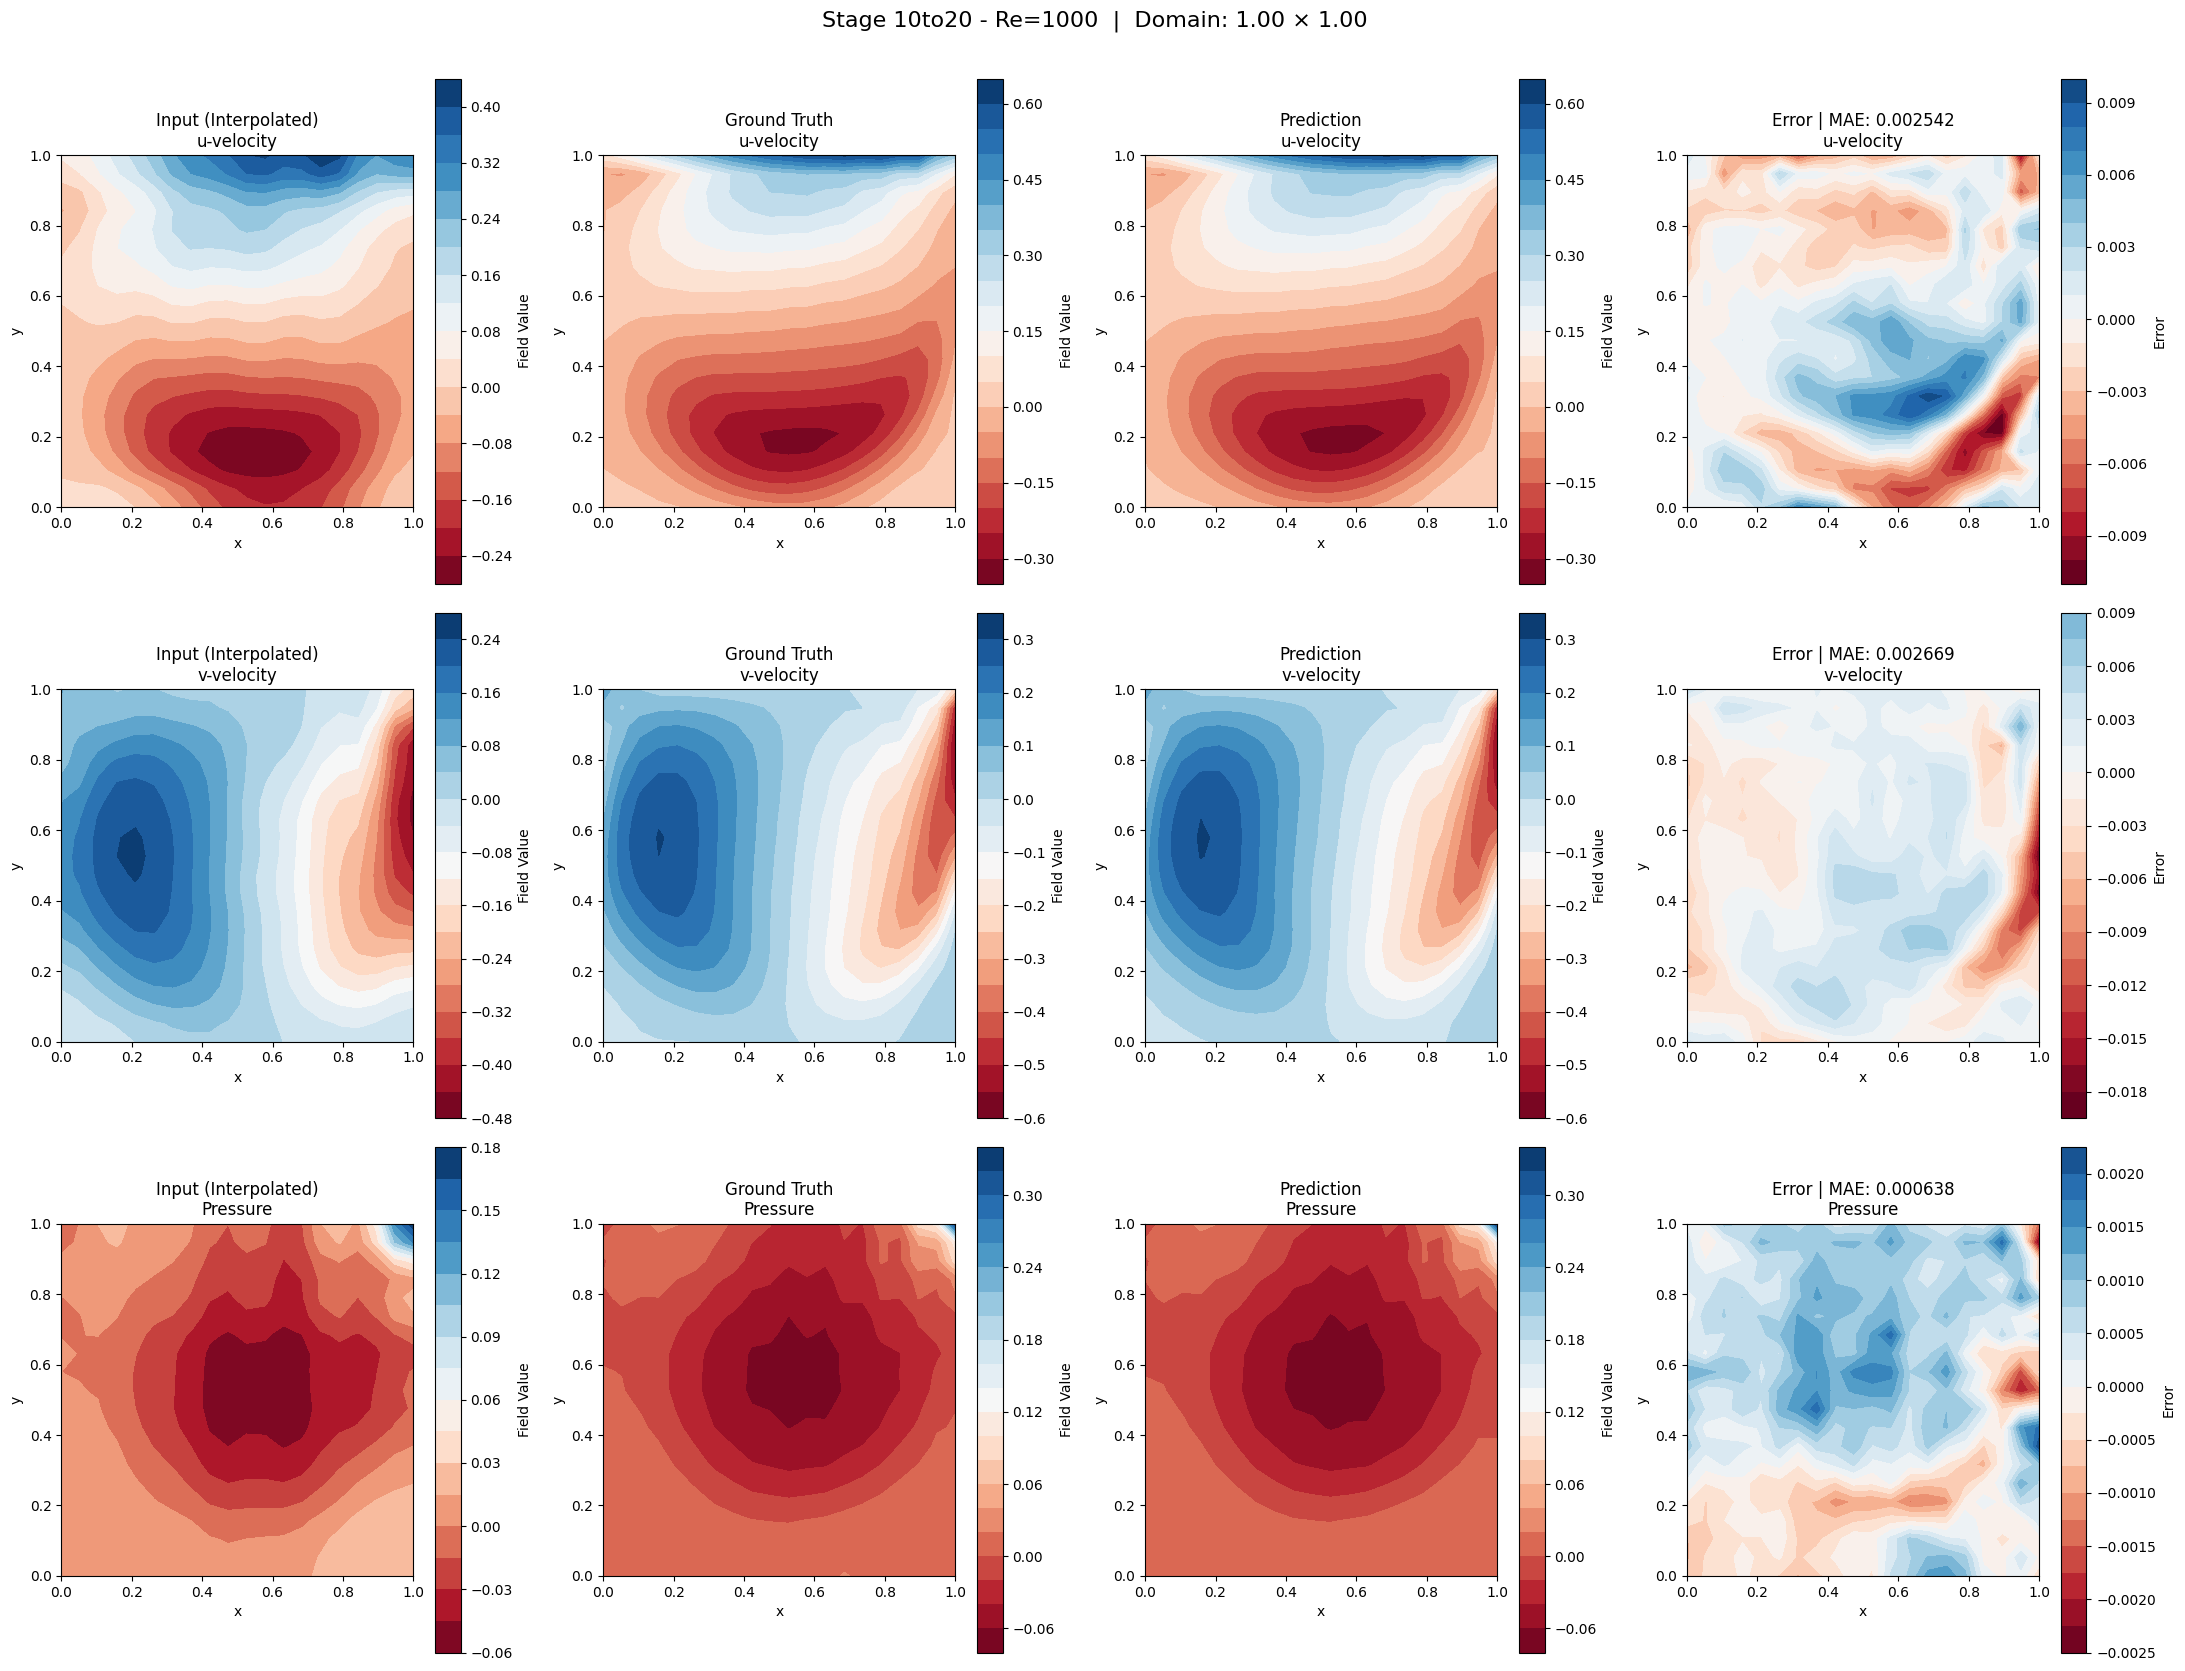

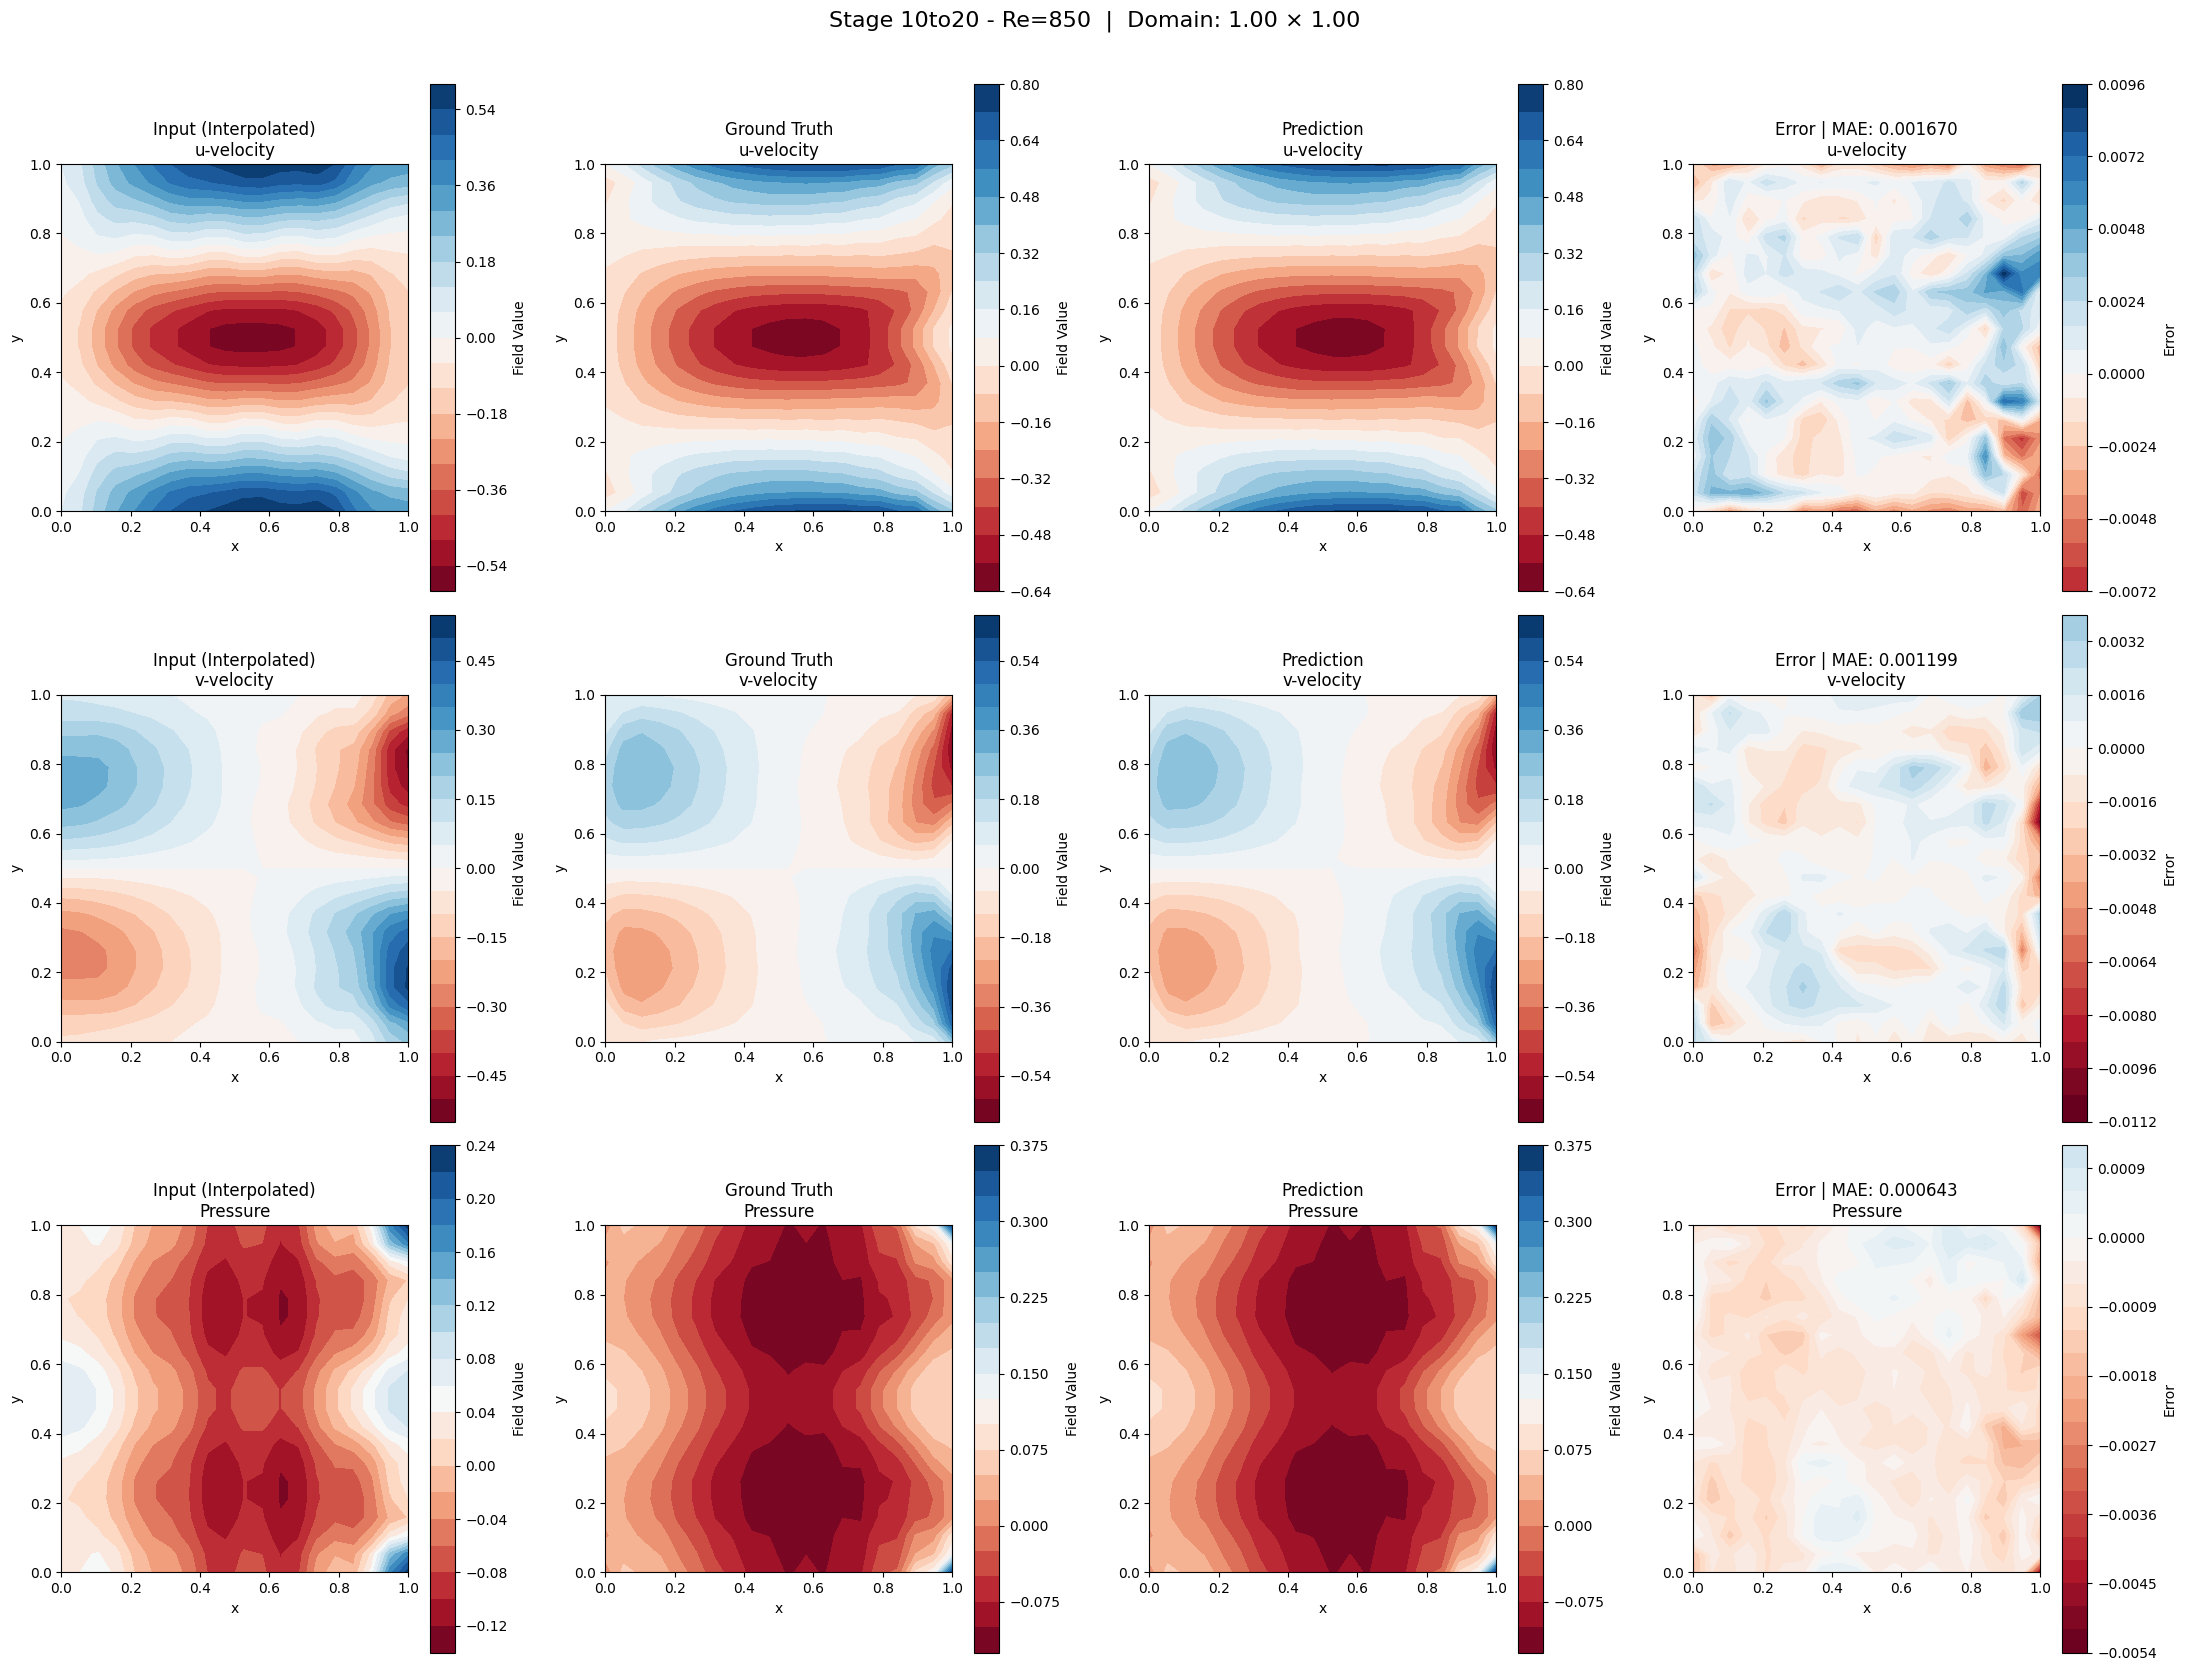

   📊 Reattached coord channels → 5-ch input: (32, 20, 20, 5)

🚀 Training Stage: 20to40
   Input shape: (32, 20, 20, 5), Target shape: (32, 40, 40, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
   Training samples: 28, Validation samples: 4


Restoring model weights from the end of the best epoch: 690.
✅ Stage 20to40 training complete.
   Best epoch: 690/700
   Best val_loss: 0.009211
   Final train_loss: 0.006289

📊 Evaluating Stage: 20to40


   MAE (u): 0.002296
   MAE (v): 0.002034
   MAE (p): 0.000664
   MAE (avg): 0.001665

💾 Saved U-Net for stage 20to40


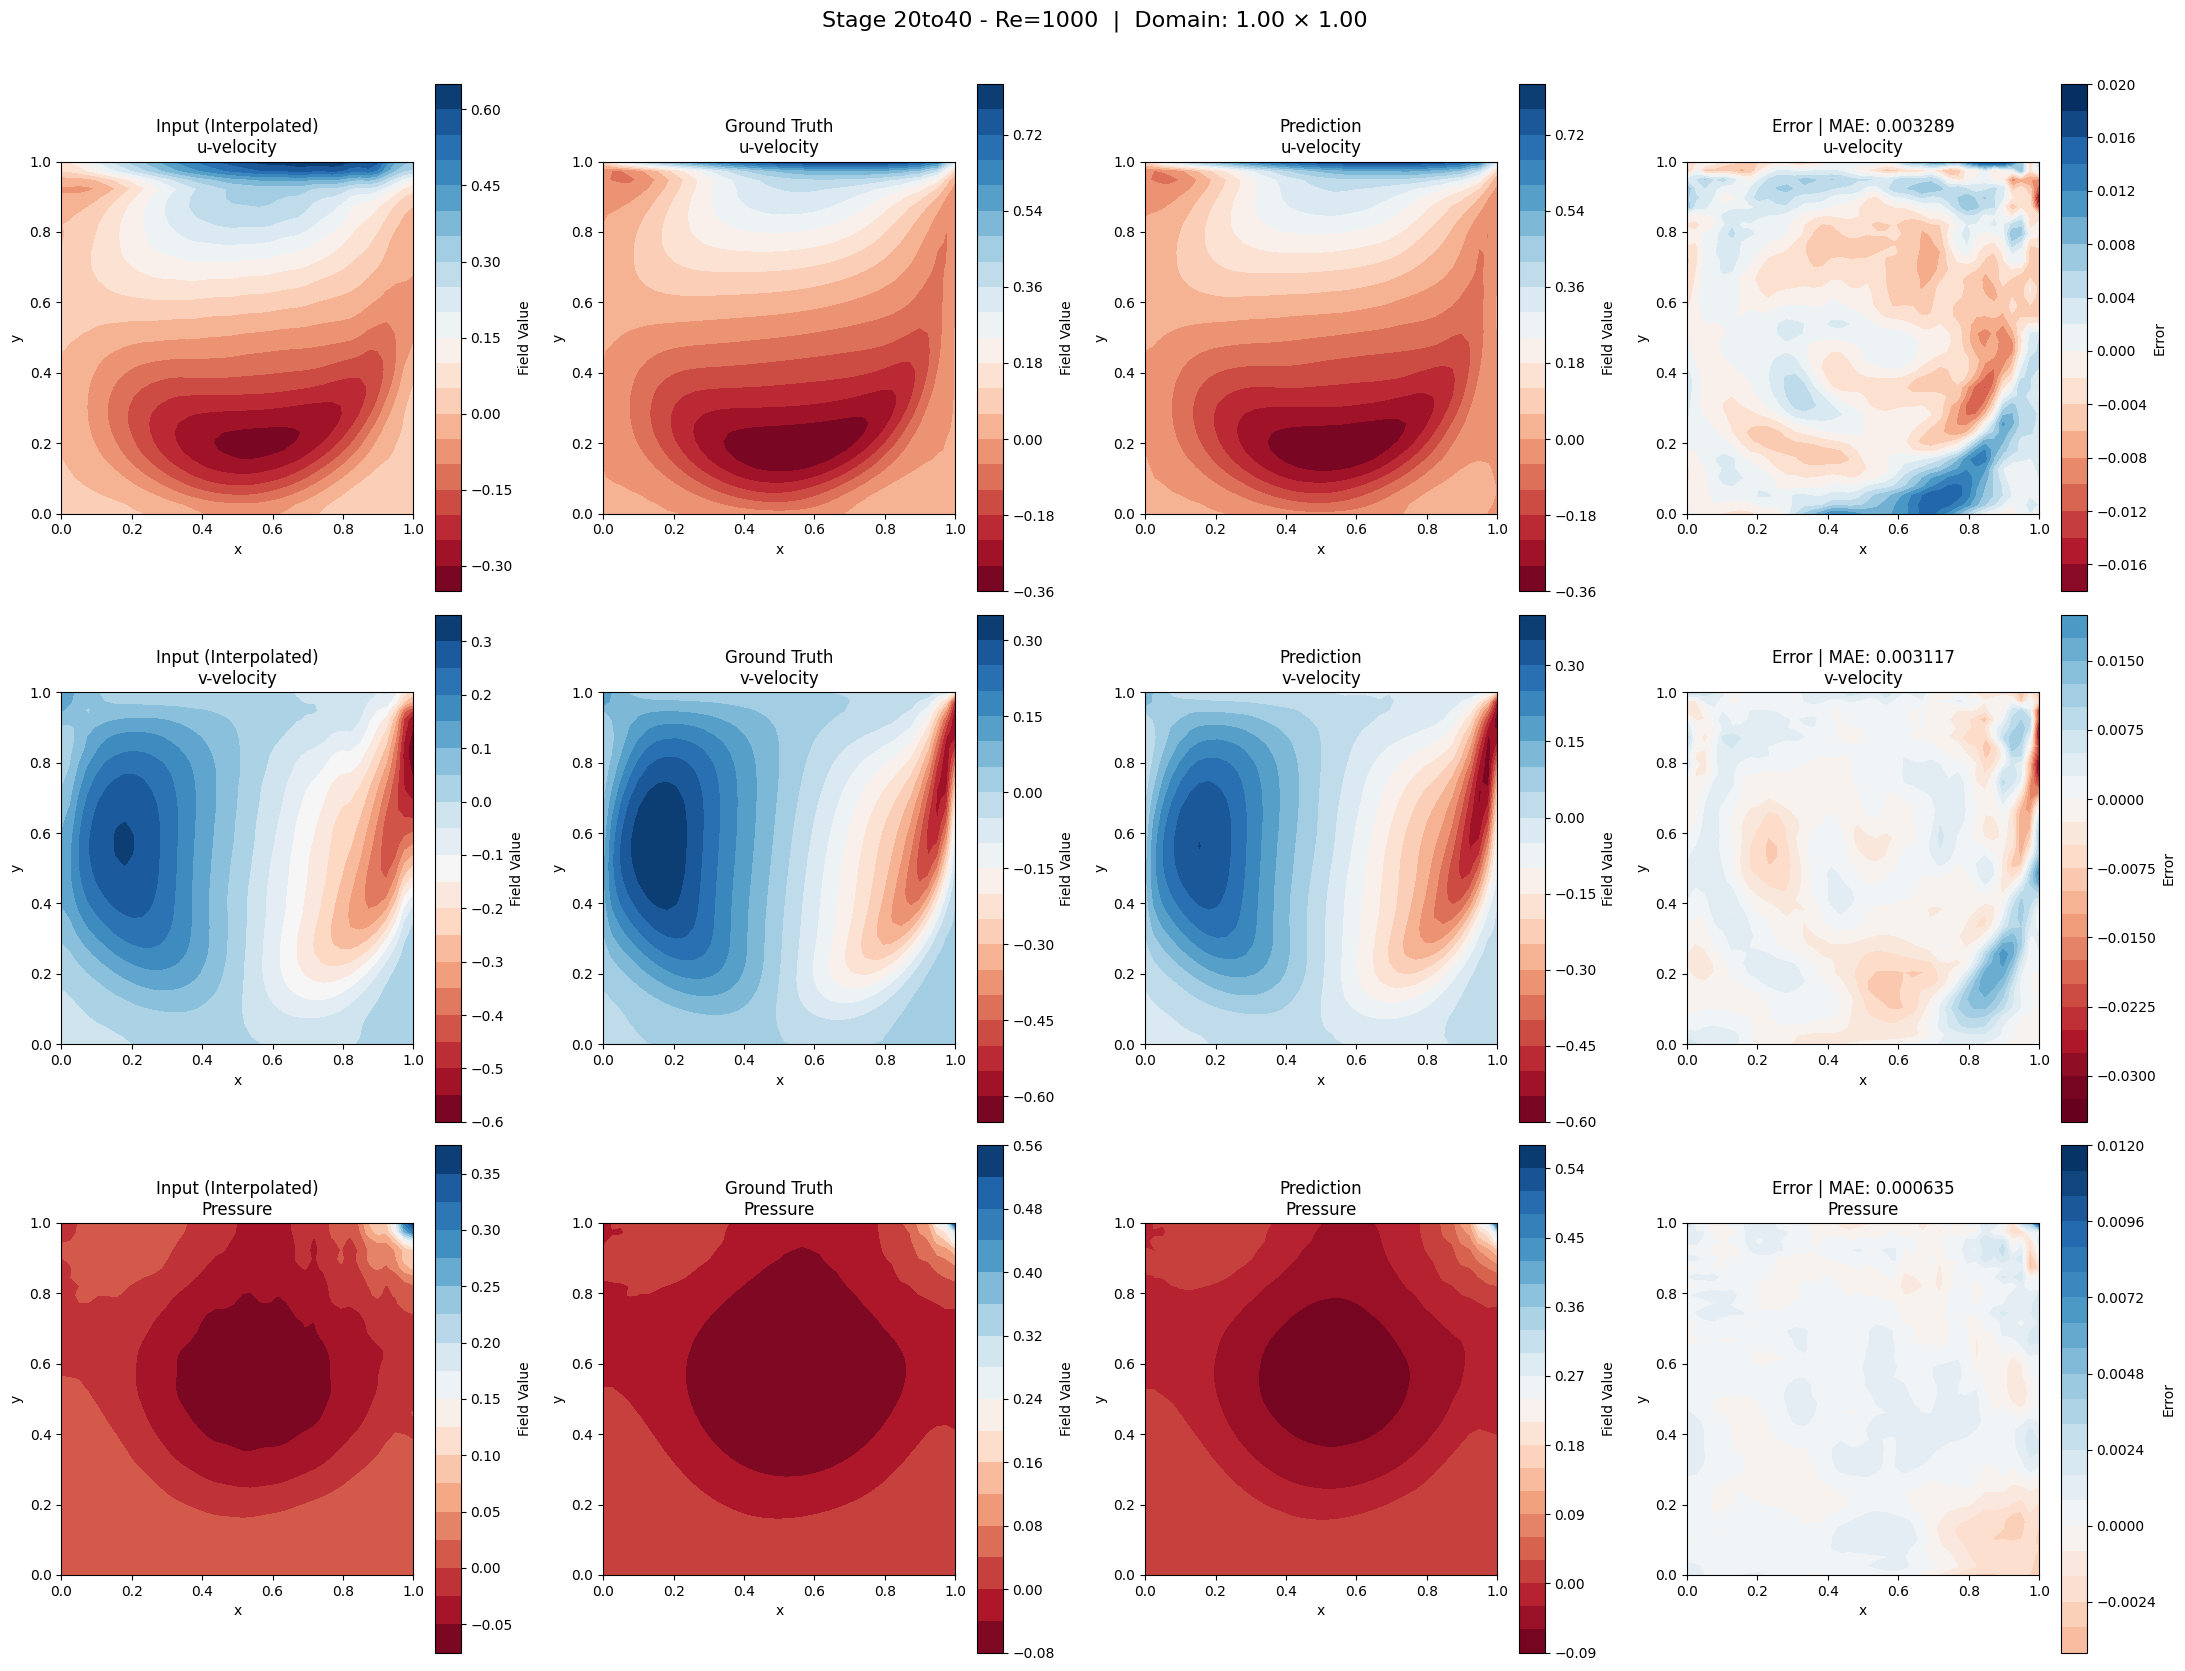

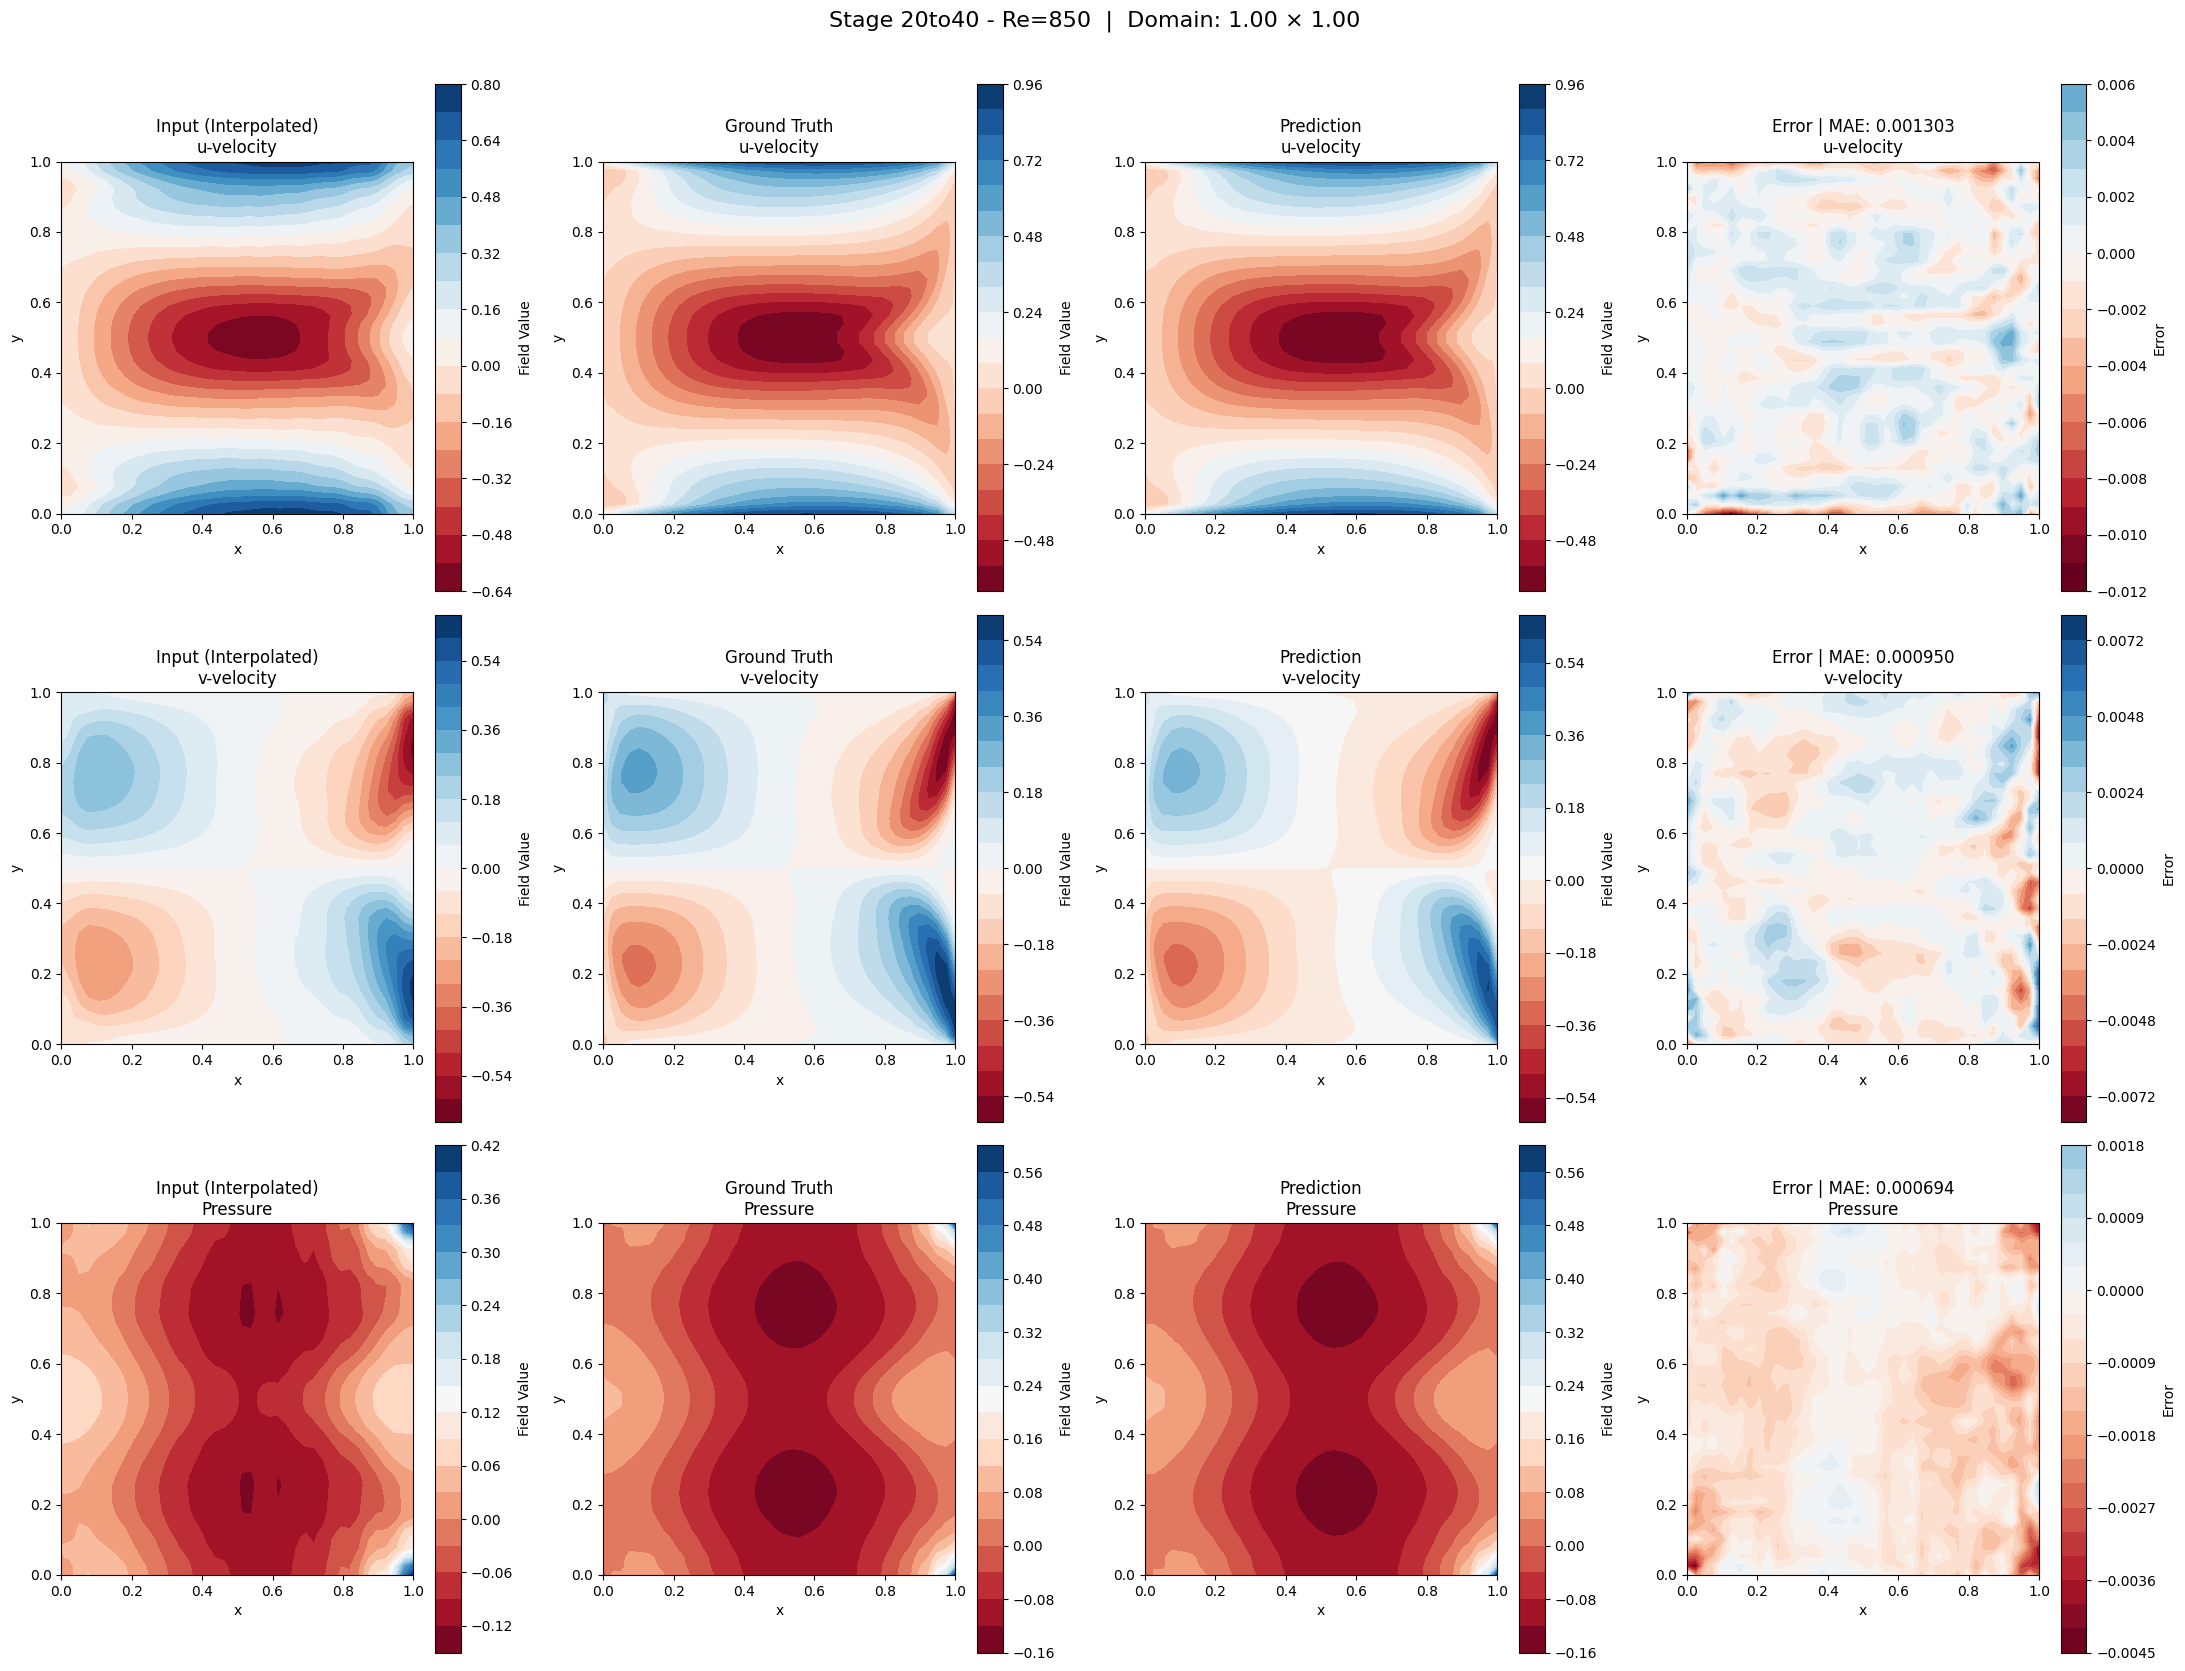

   📊 Reattached coord channels → 5-ch input: (32, 40, 40, 5)

🚀 Training Stage: 40to80
   Input shape: (32, 40, 40, 5), Target shape: (32, 80, 80, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
   Training samples: 28, Validation samples: 4


Restoring model weights from the end of the best epoch: 675.
✅ Stage 40to80 training complete.
   Best epoch: 675/700
   Best val_loss: 0.004578
   Final train_loss: 0.004536

📊 Evaluating Stage: 40to80


   MAE (u): 0.002131
   MAE (v): 0.001810
   MAE (p): 0.000661
   MAE (avg): 0.001534

💾 Saved U-Net for stage 40to80


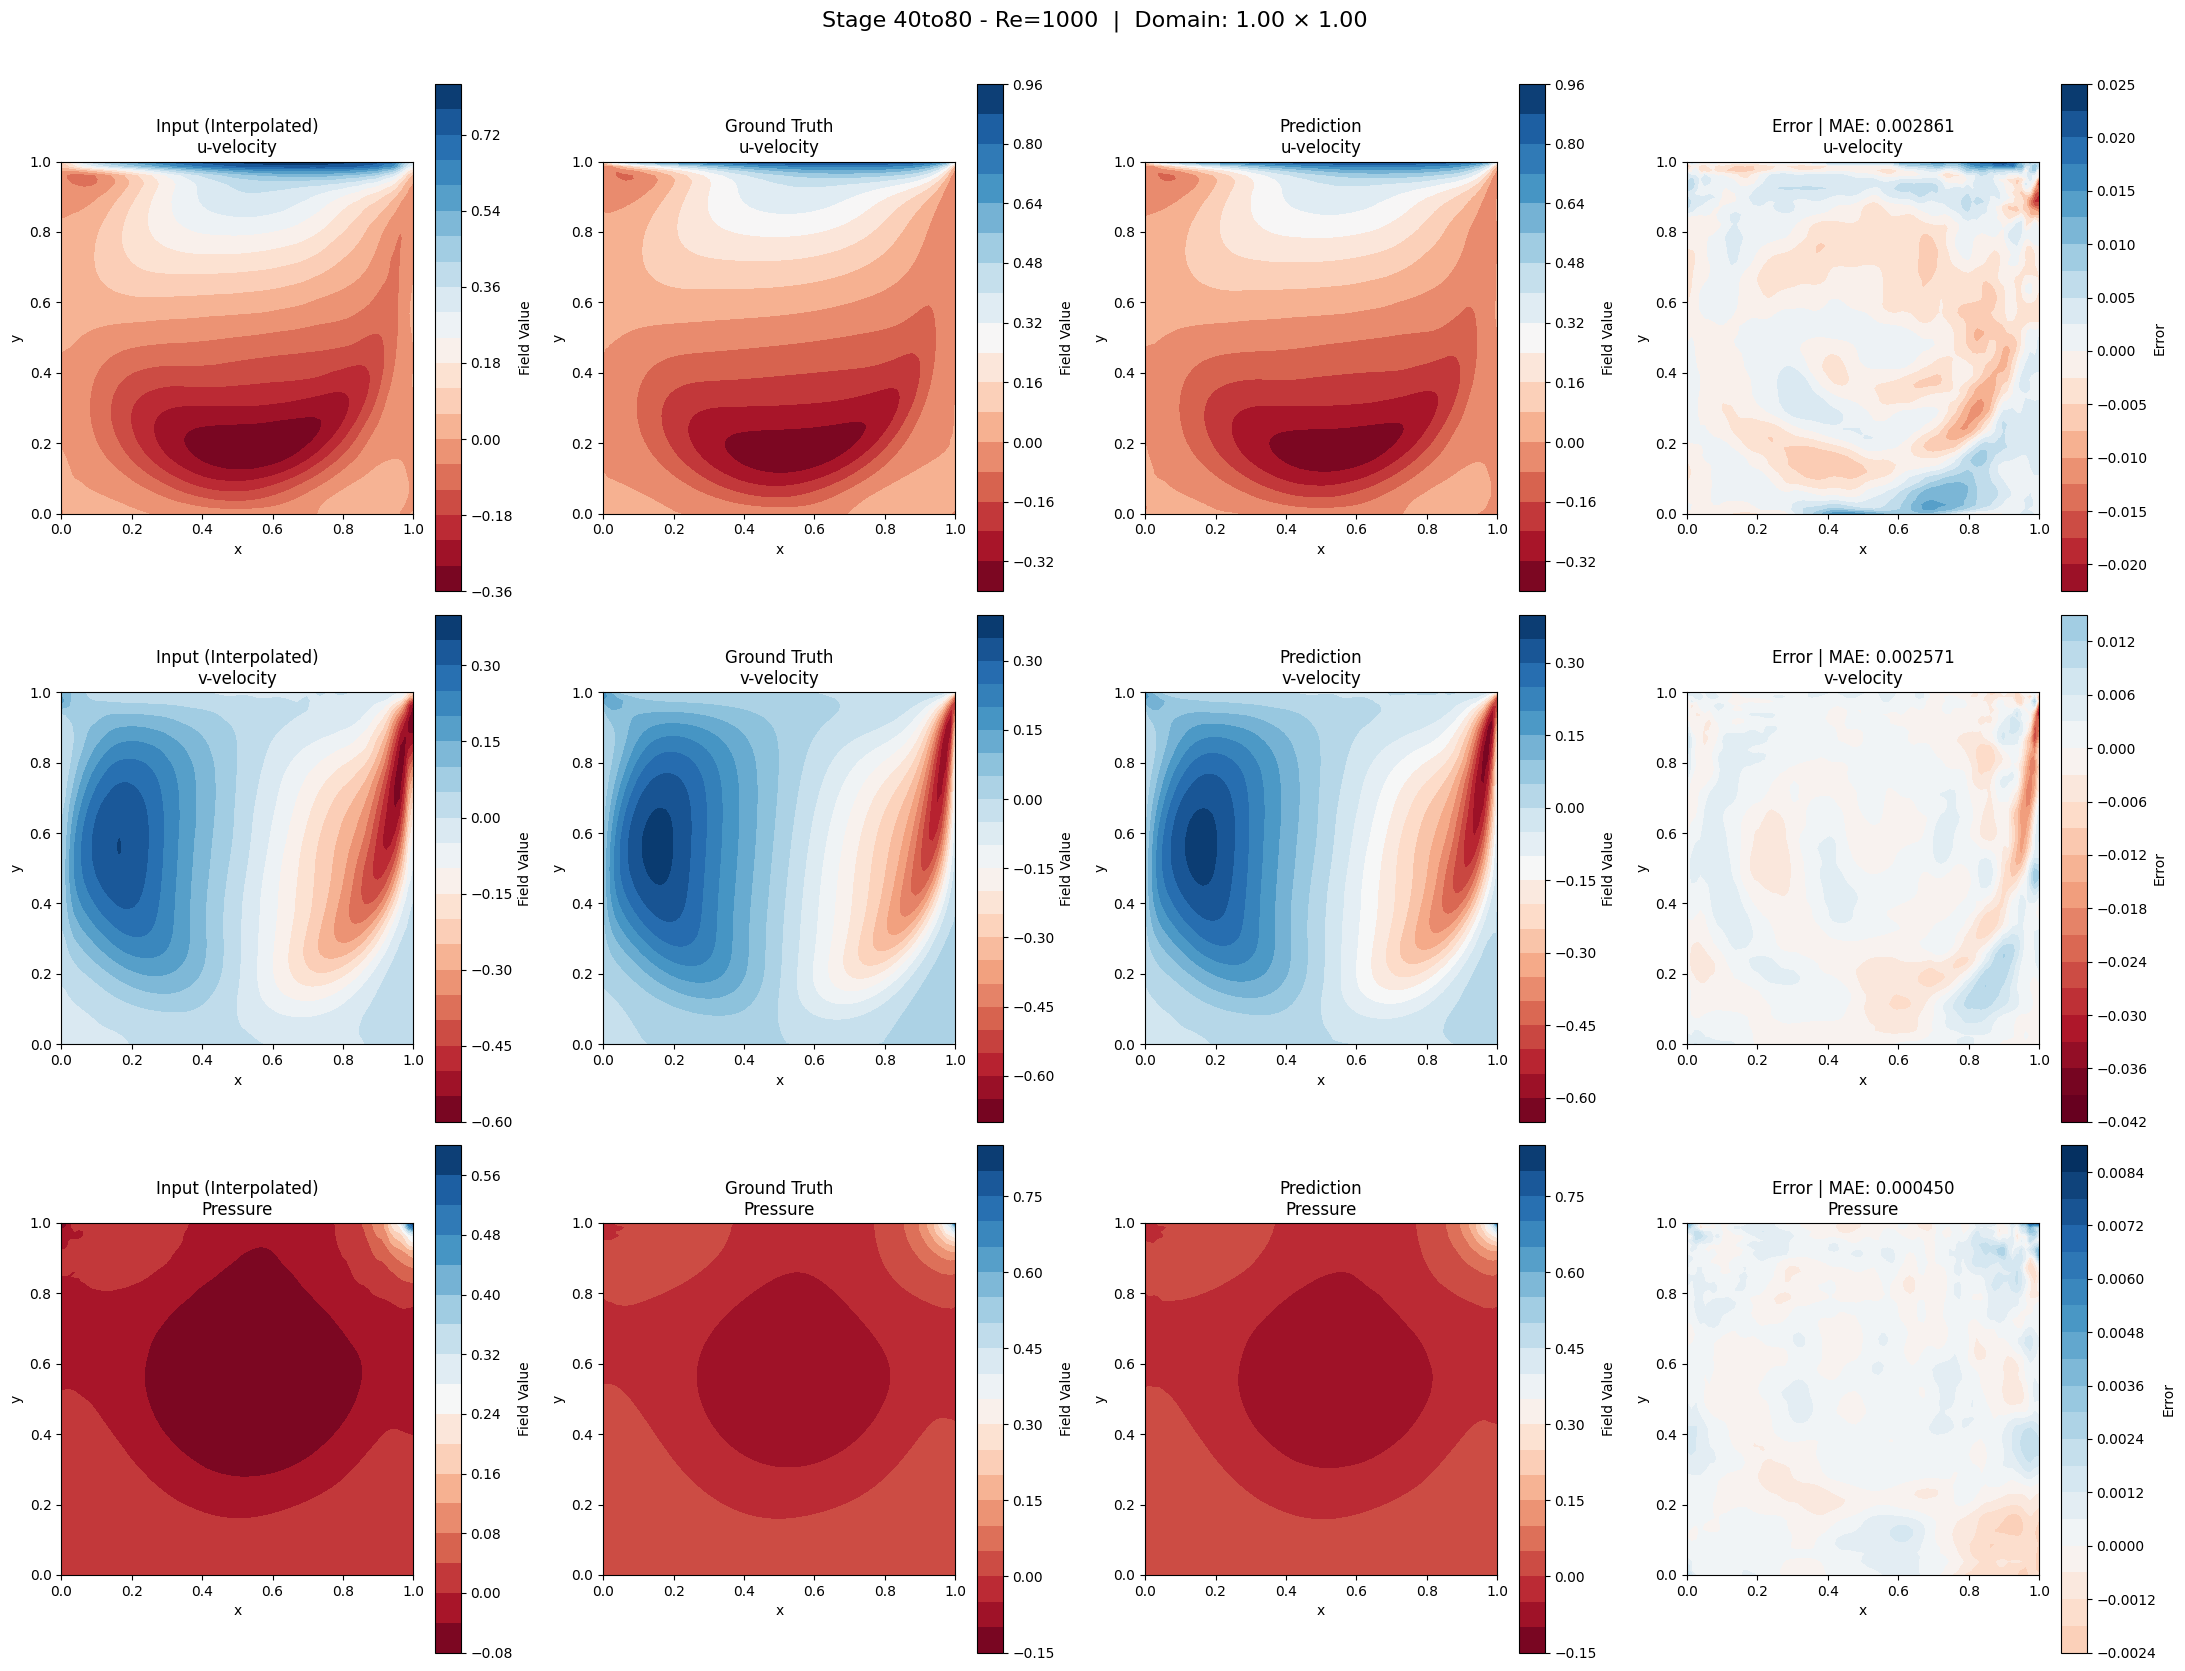

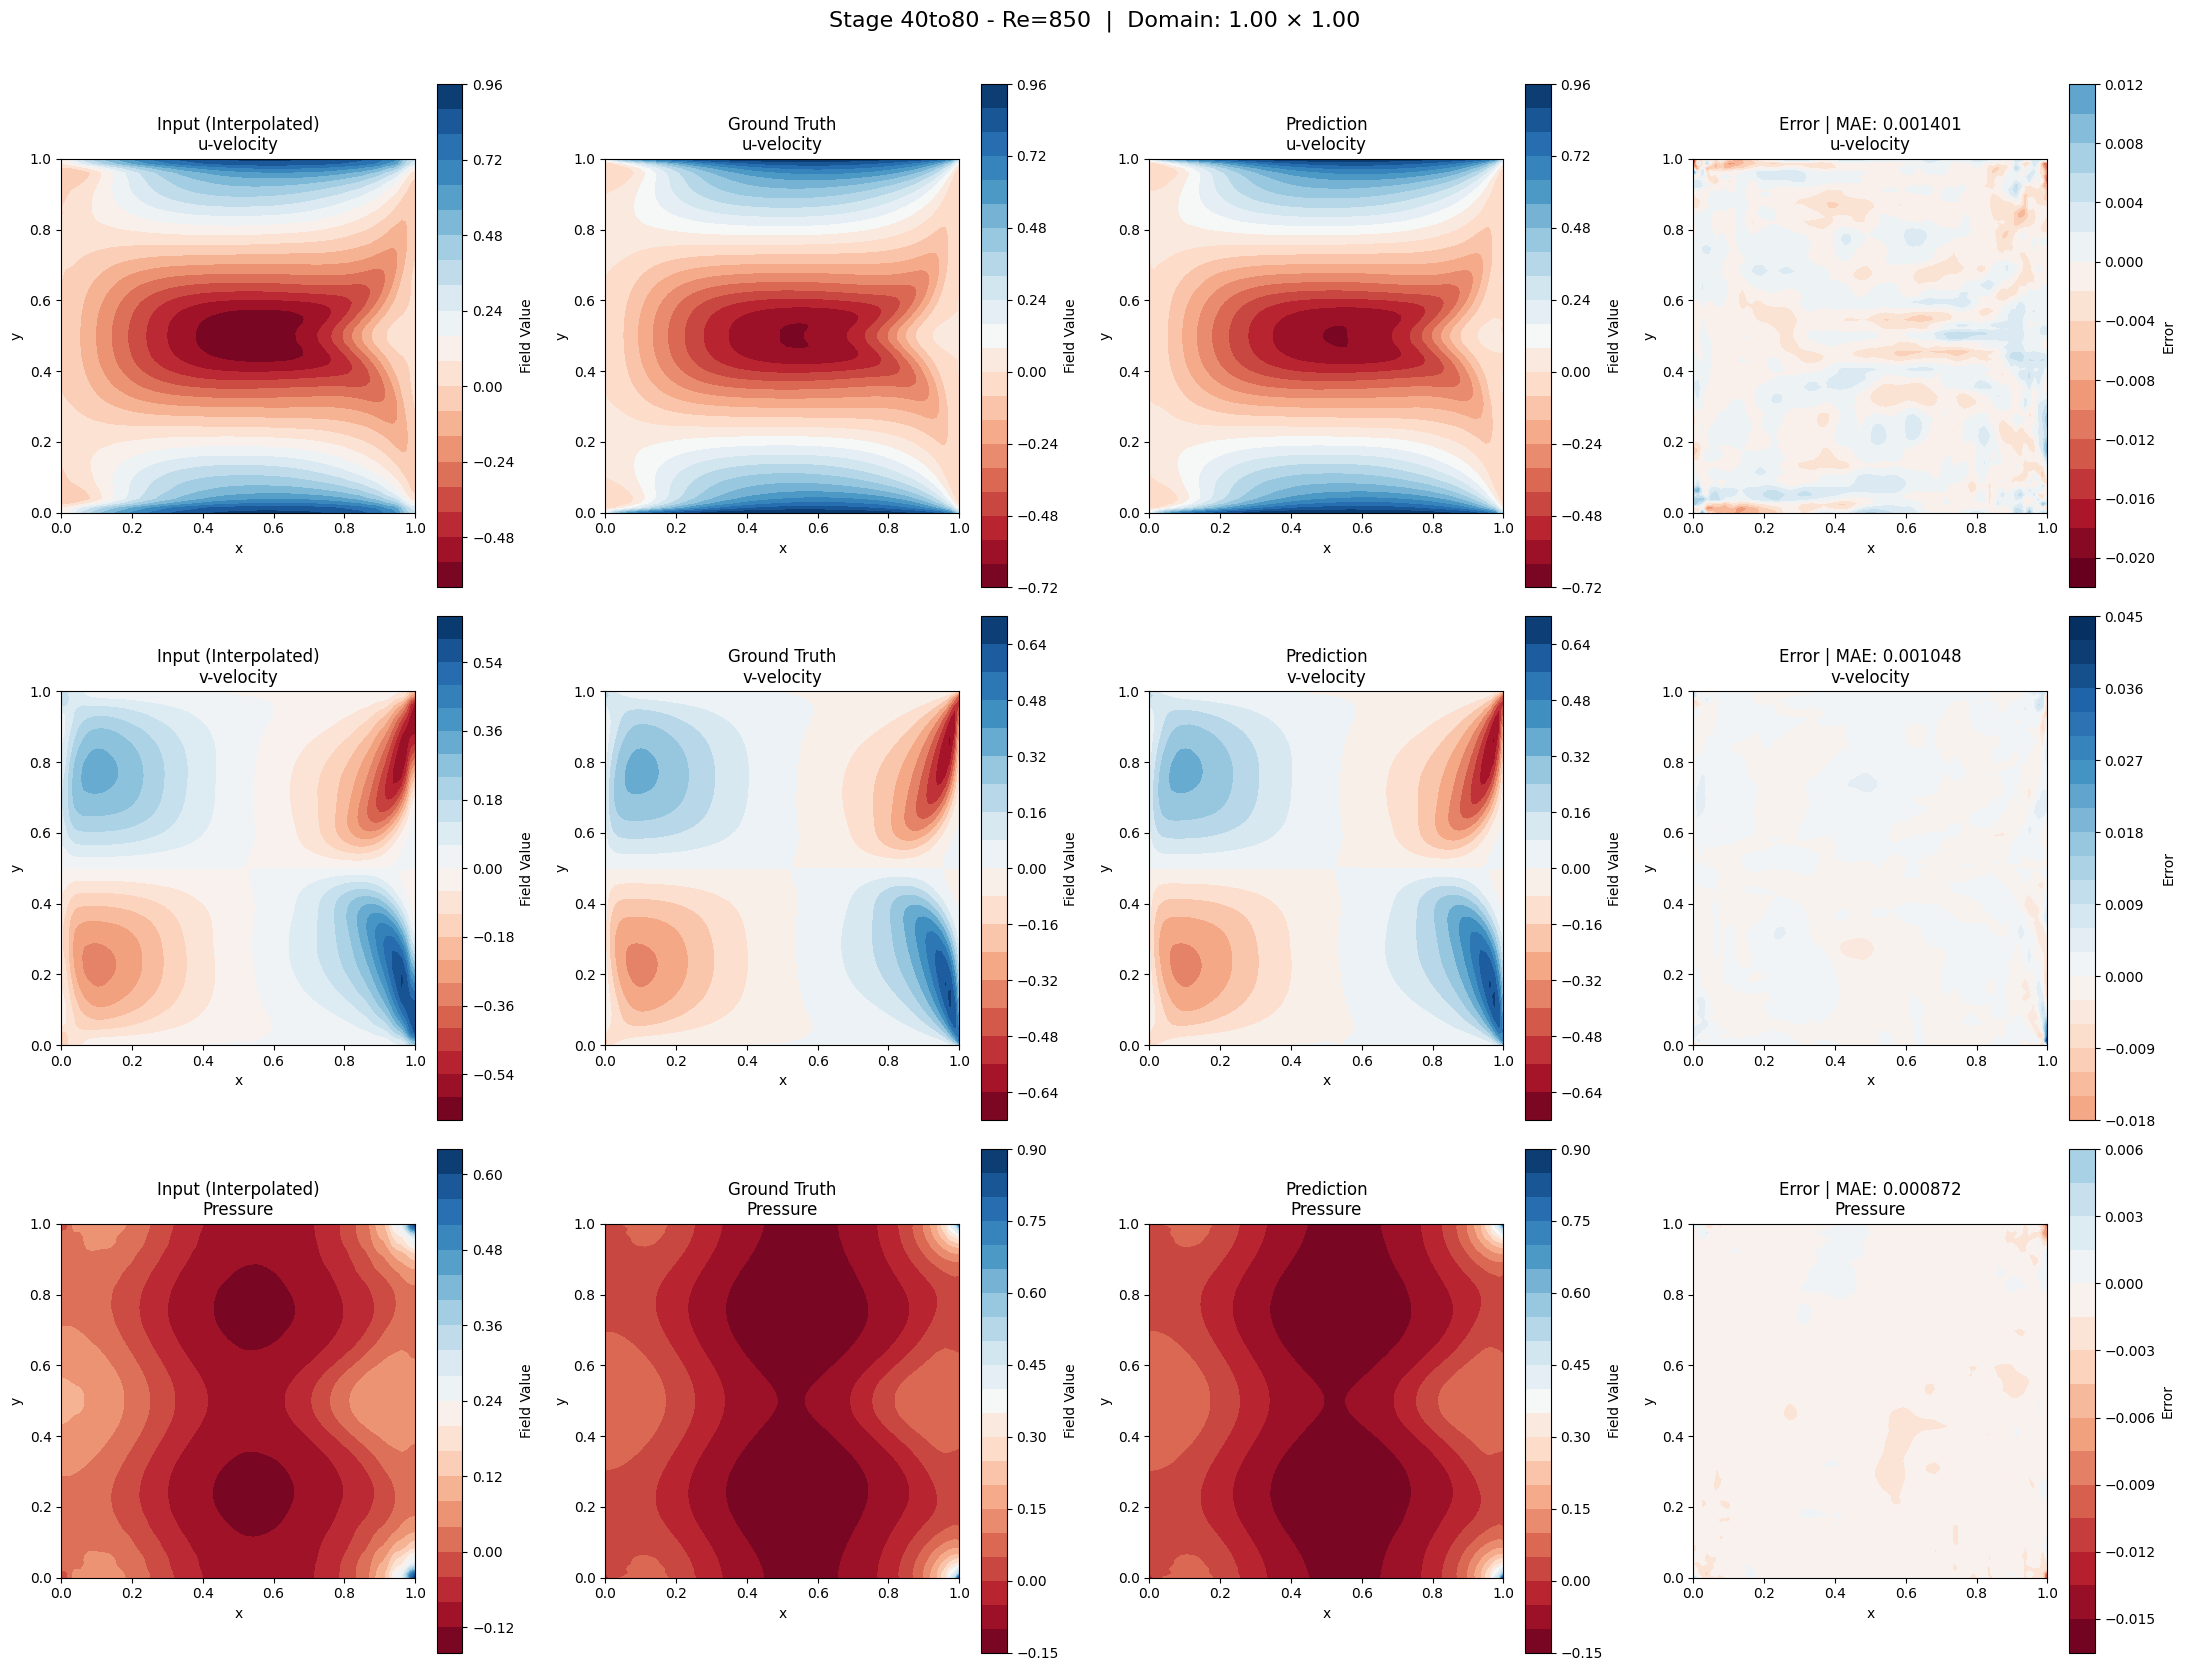

   📊 Reattached coord channels → 5-ch input: (32, 80, 80, 5)

🚀 Training Stage: 80to200
   Input shape: (32, 80, 80, 5), Target shape: (32, 200, 200, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
   Training samples: 28, Validation samples: 4


Restoring model weights from the end of the best epoch: 697.
✅ Stage 80to200 training complete.
   Best epoch: 697/700
   Best val_loss: 0.003593
   Final train_loss: 0.003539

📊 Evaluating Stage: 80to200


   MAE (u): 0.002196
   MAE (v): 0.001856
   MAE (p): 0.000648
   MAE (avg): 0.001567

💾 Saved U-Net for stage 80to200


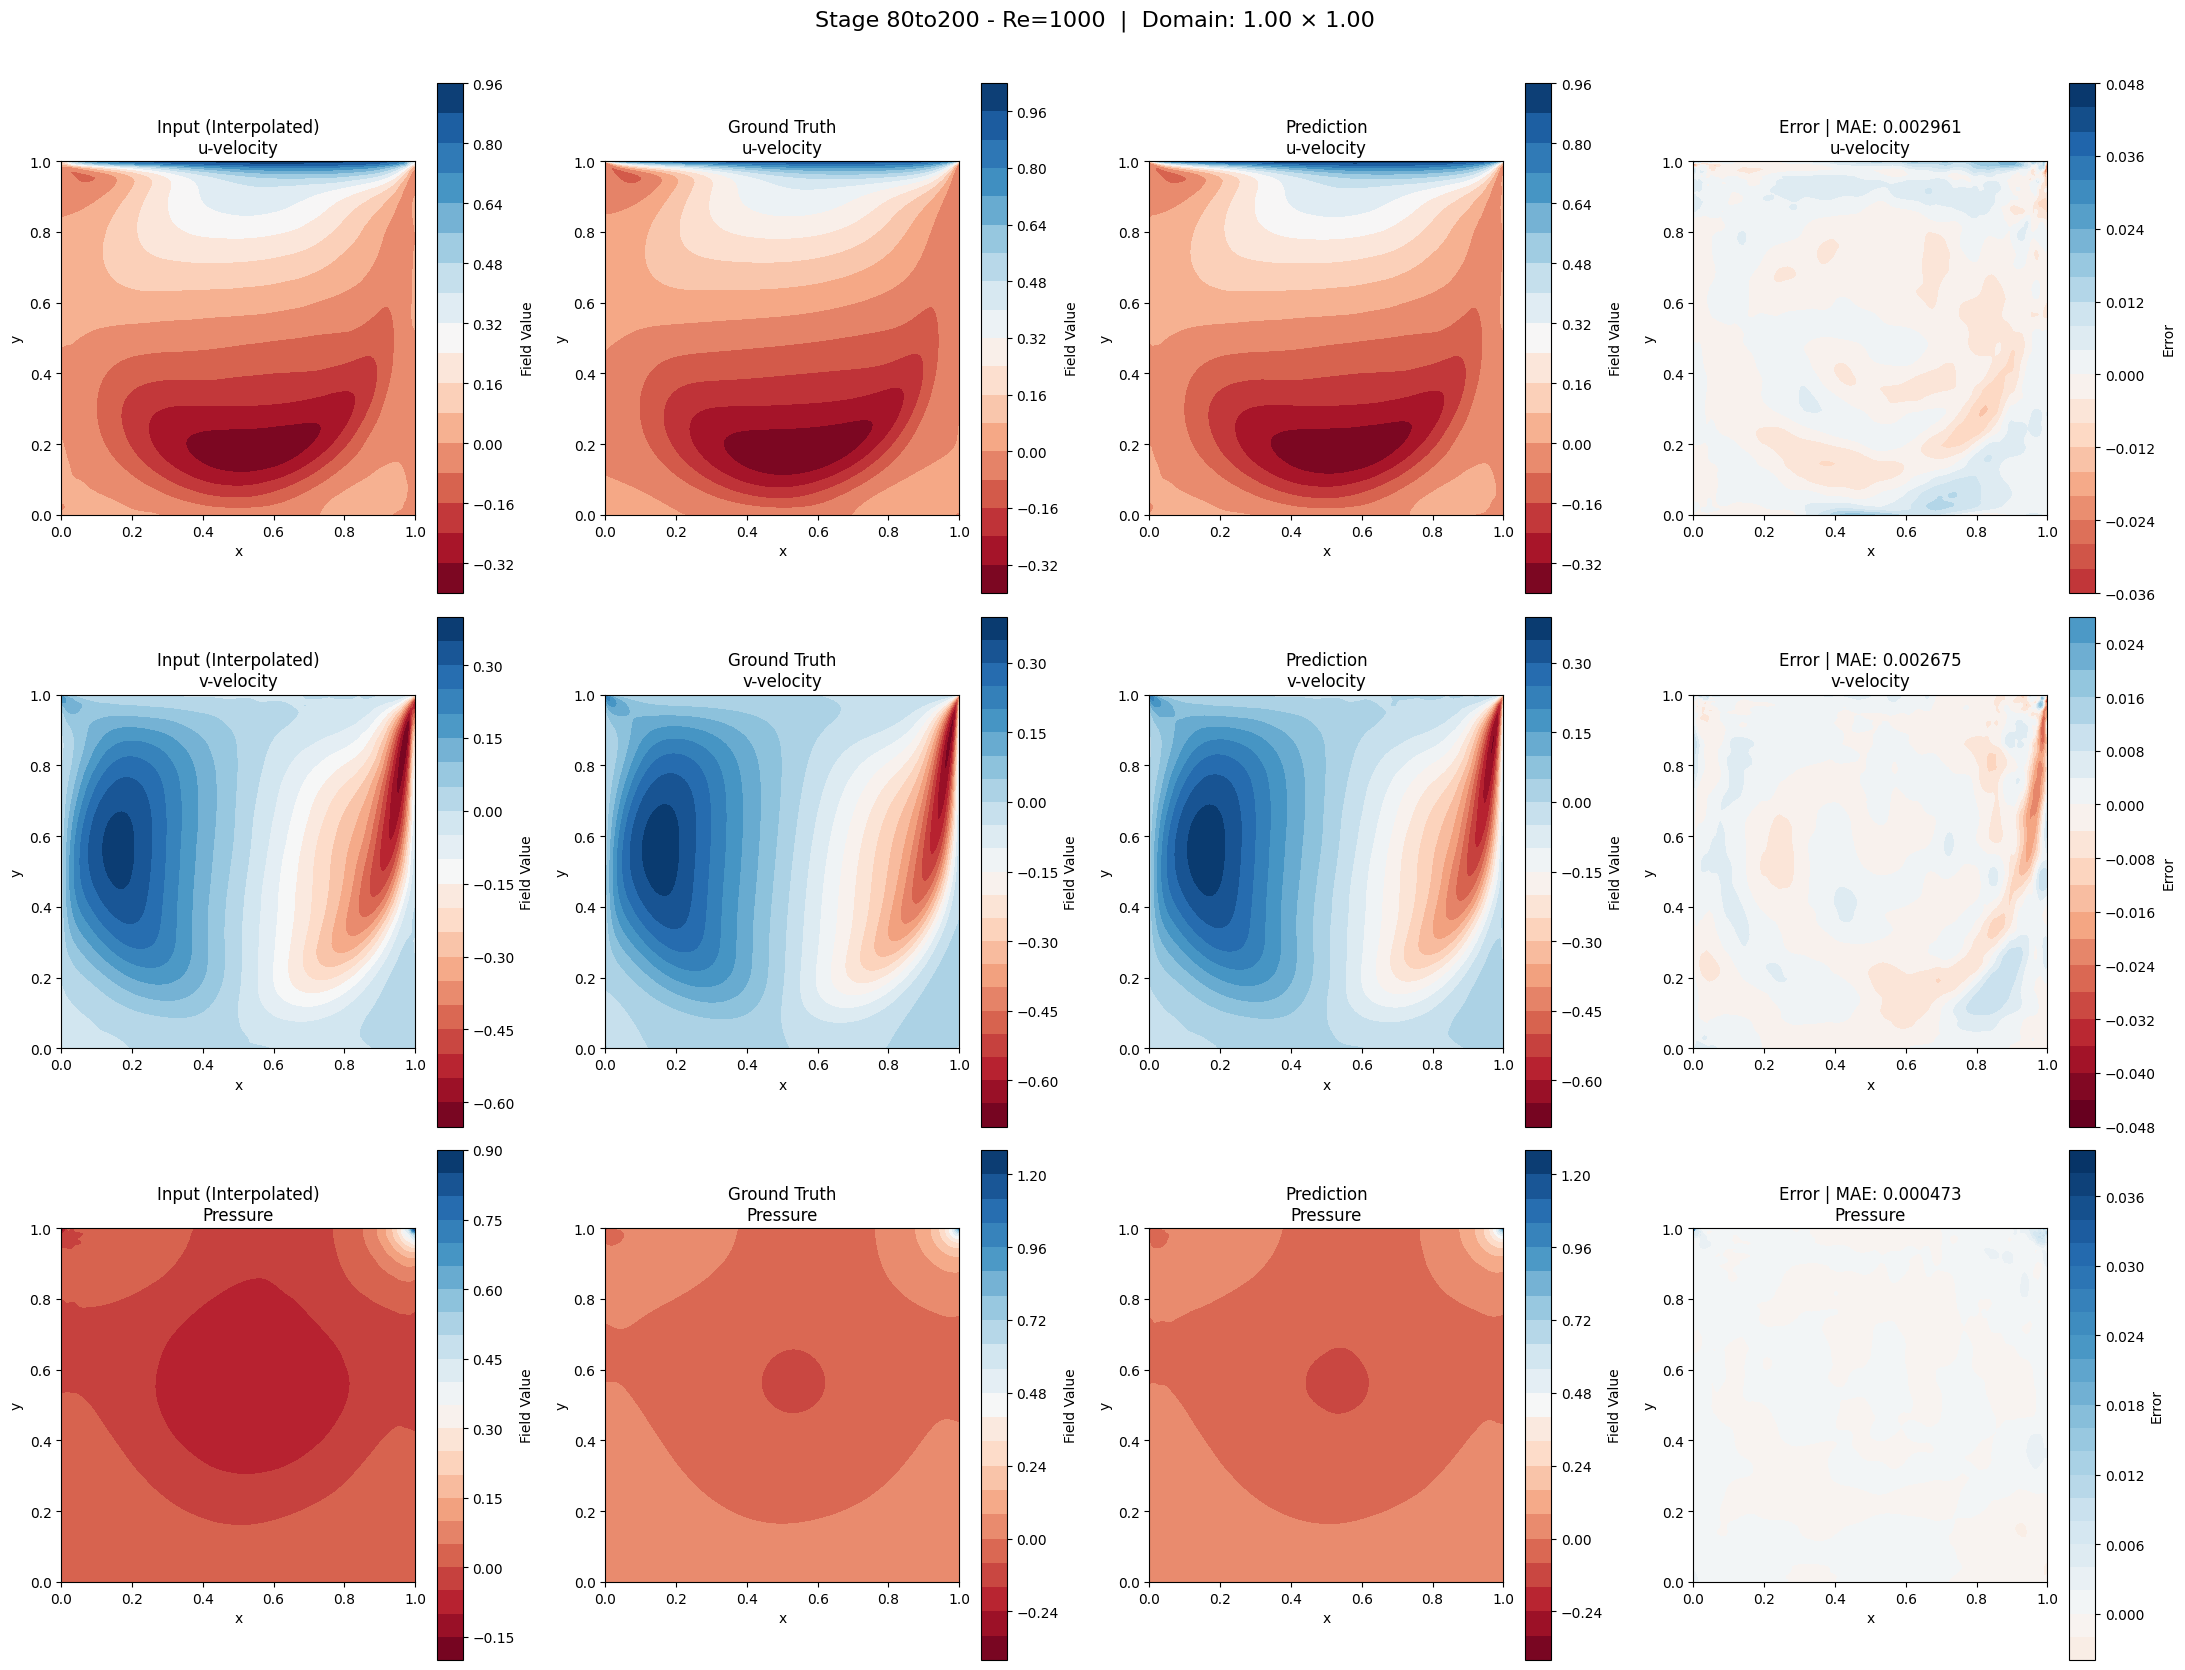

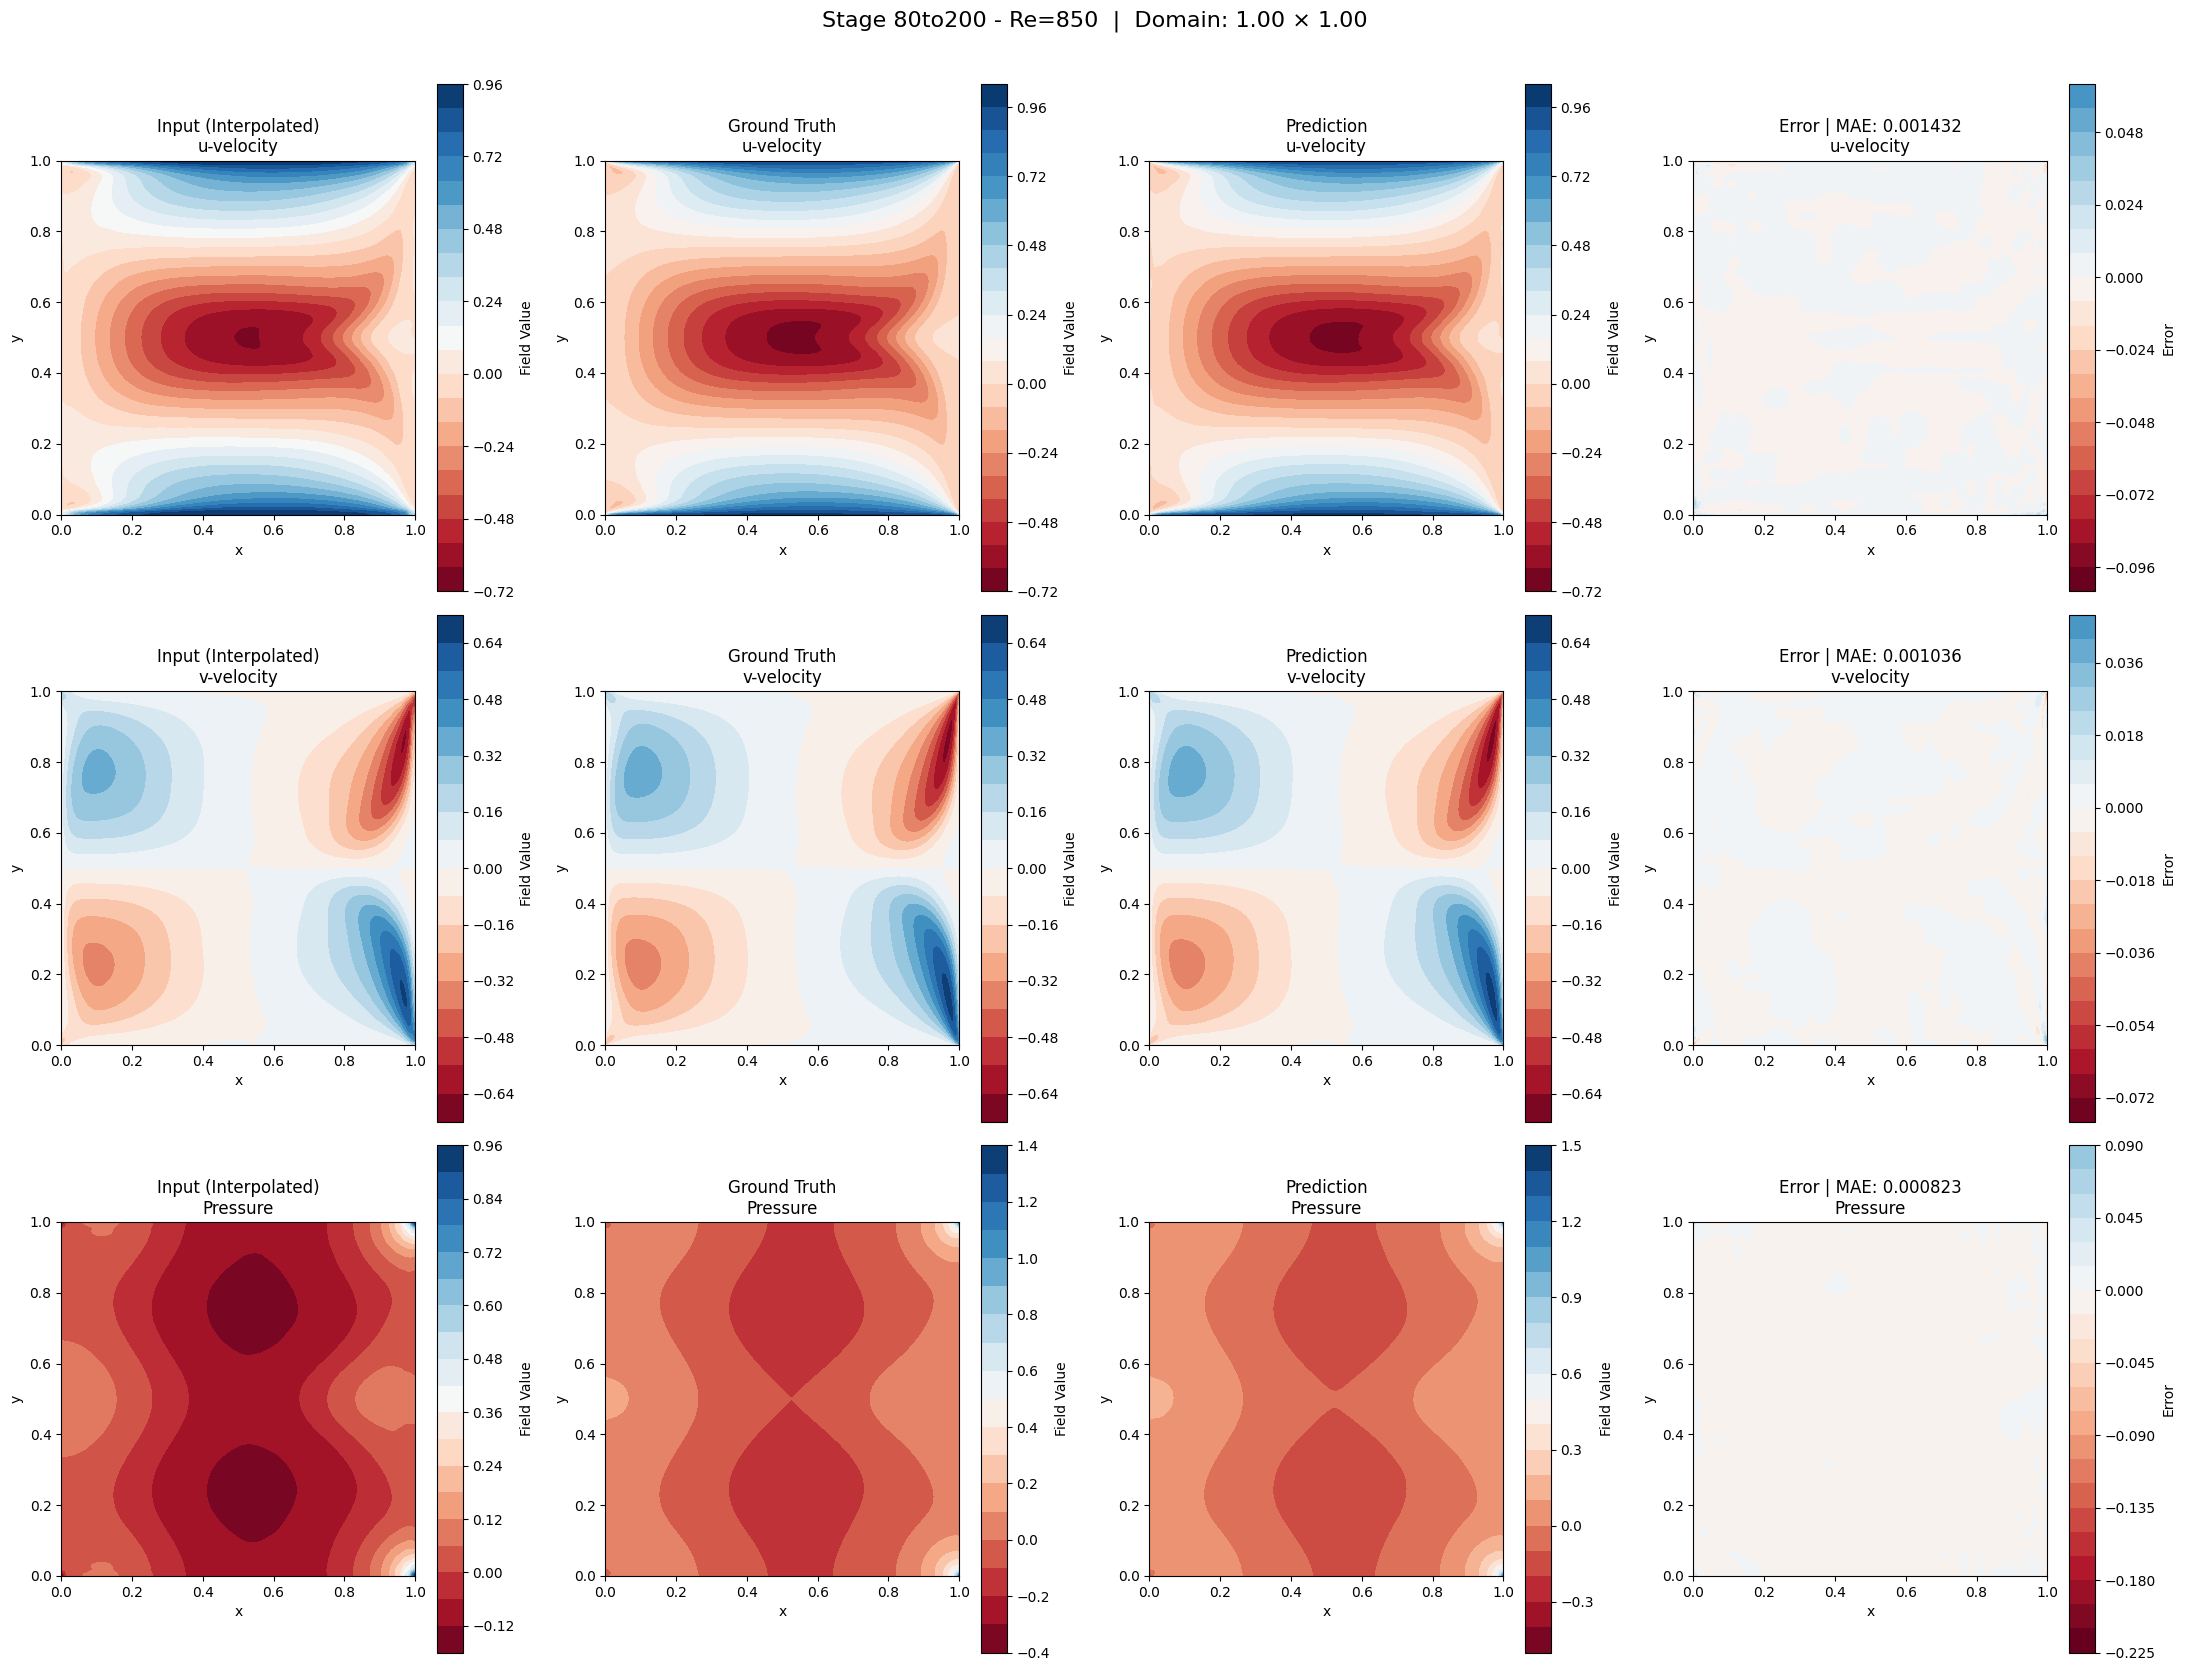

   📊 Reattached coord channels → 5-ch input: (32, 200, 200, 5)

🚀 Training Stage: 200to400
   Input shape: (32, 200, 200, 5), Target shape: (32, 400, 400, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
   Training samples: 28, Validation samples: 4


Restoring model weights from the end of the best epoch: 692.
✅ Stage 200to400 training complete.
   Best epoch: 692/700
   Best val_loss: 0.002759
   Final train_loss: 0.002770

📊 Evaluating Stage: 200to400


   MAE (u): 0.002484
   MAE (v): 0.002173
   MAE (p): 0.001058
   MAE (avg): 0.001905

💾 Saved U-Net for stage 200to400


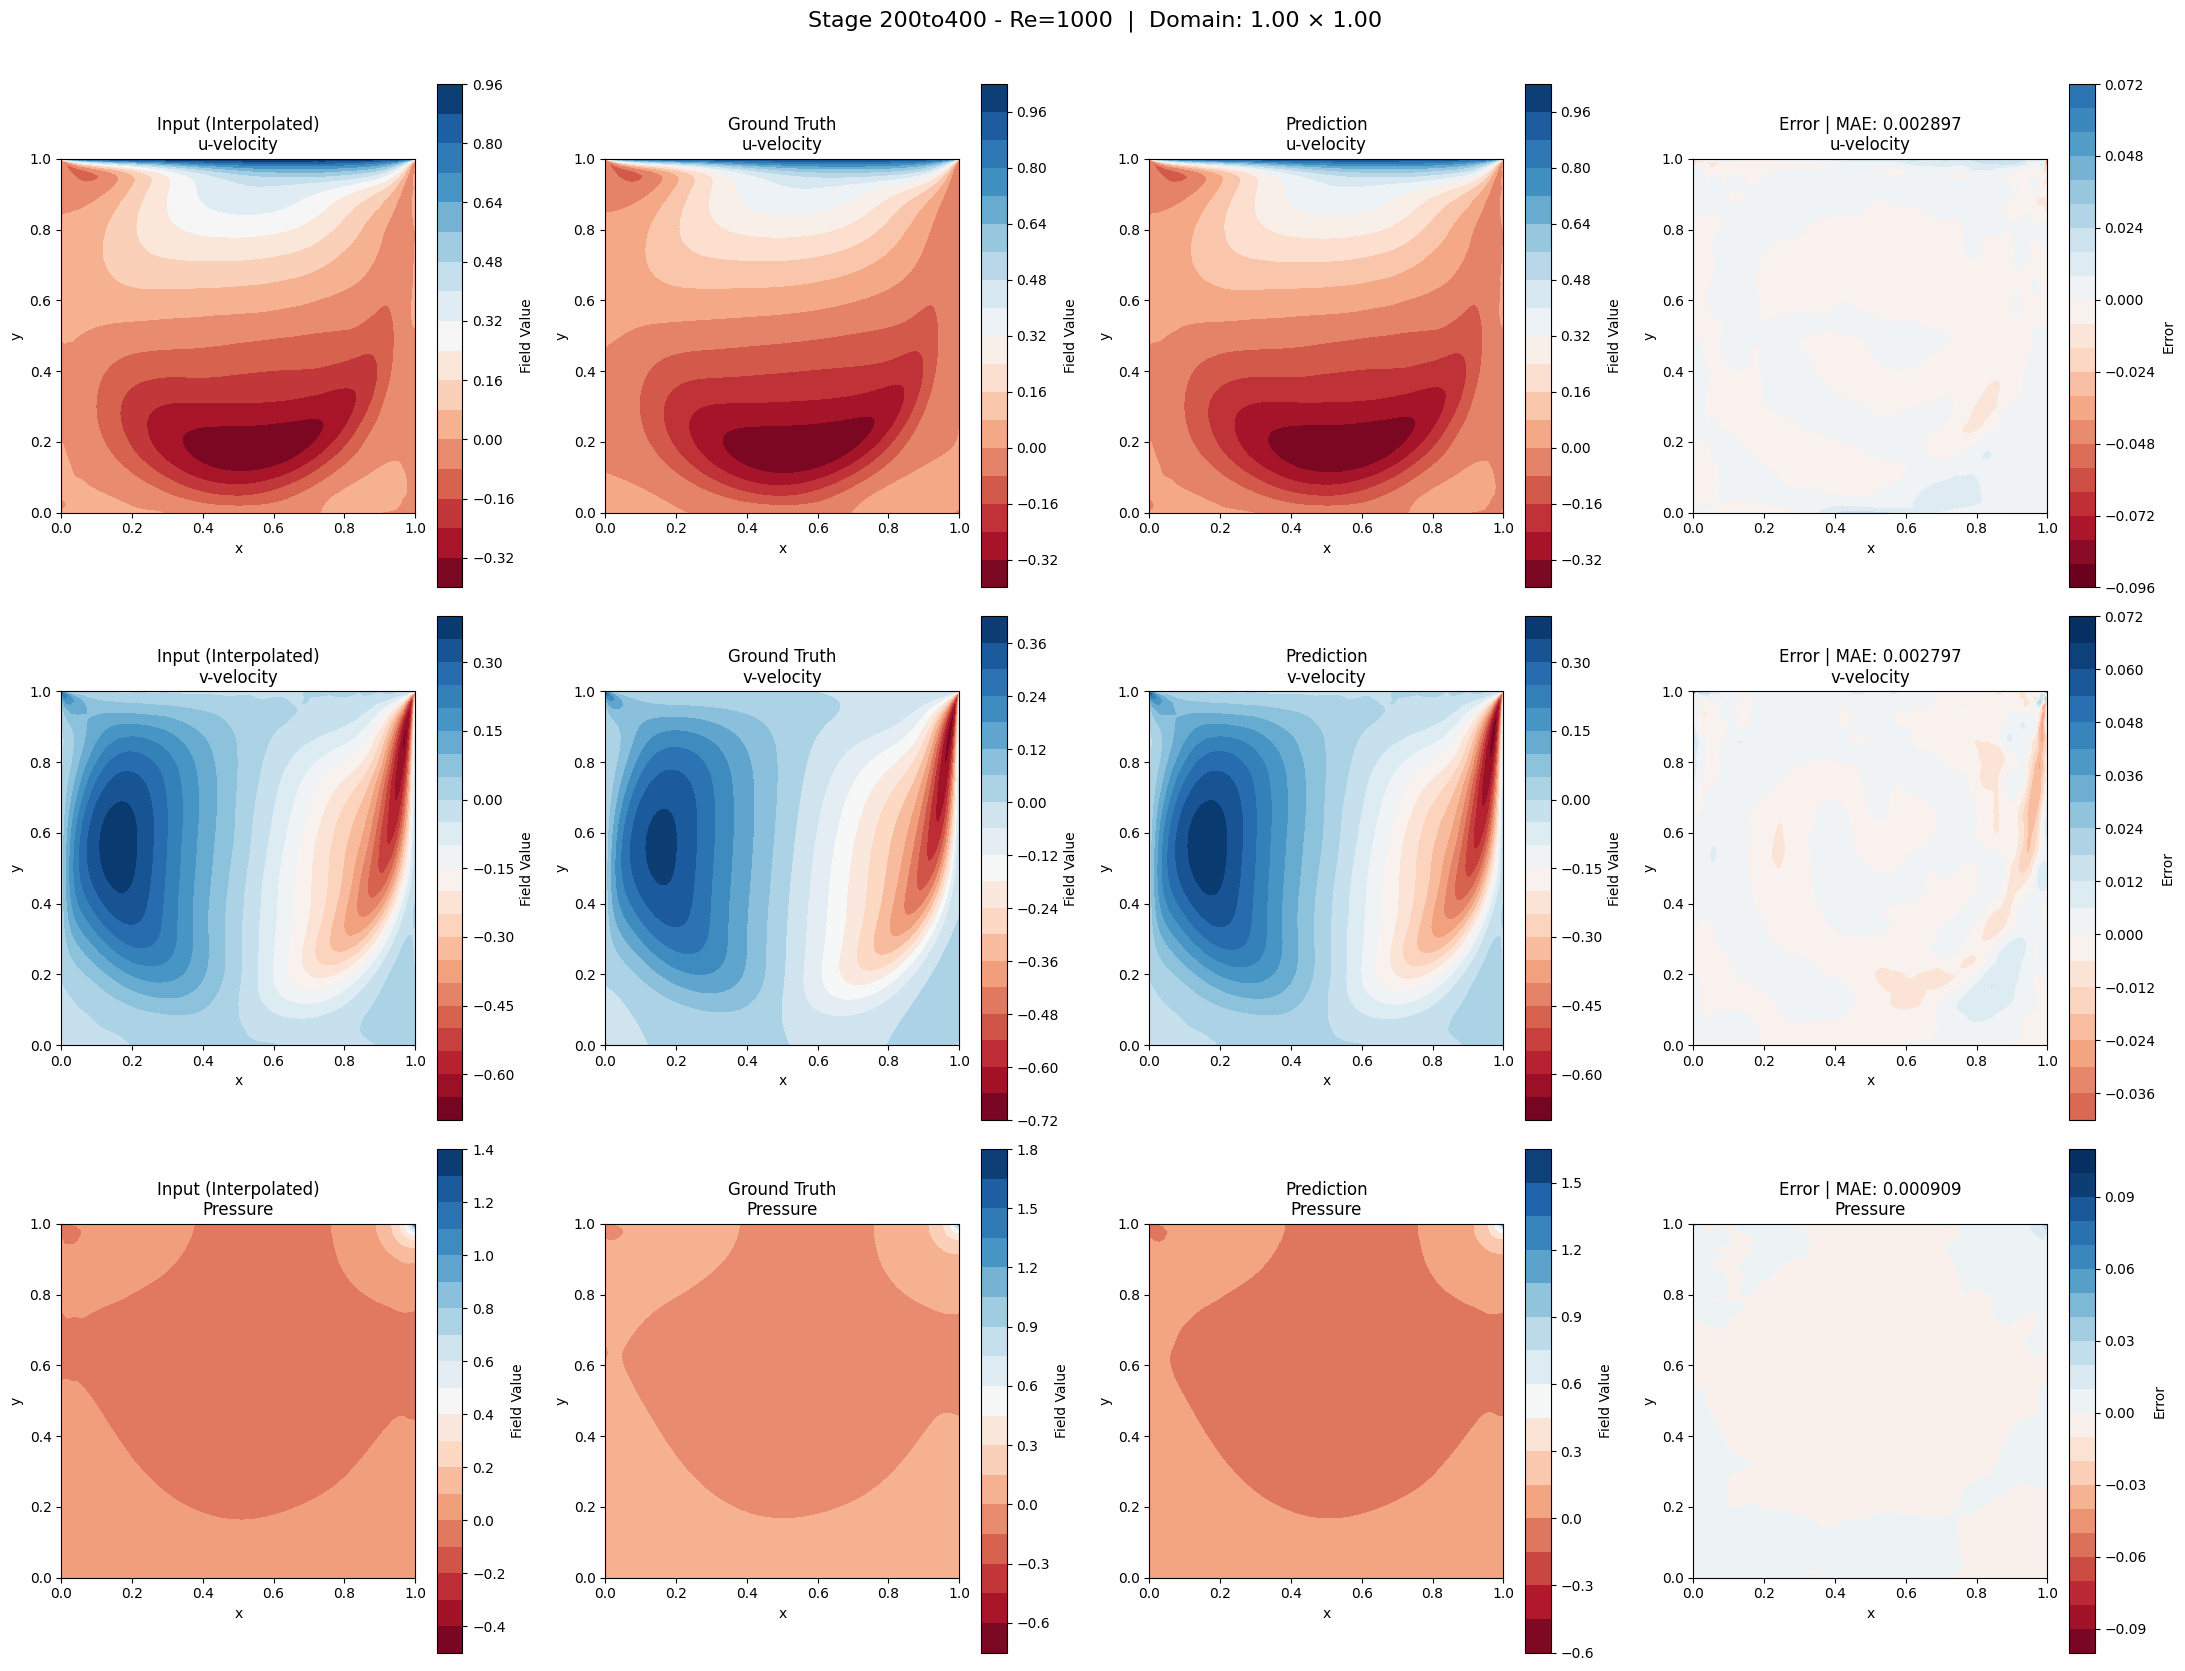

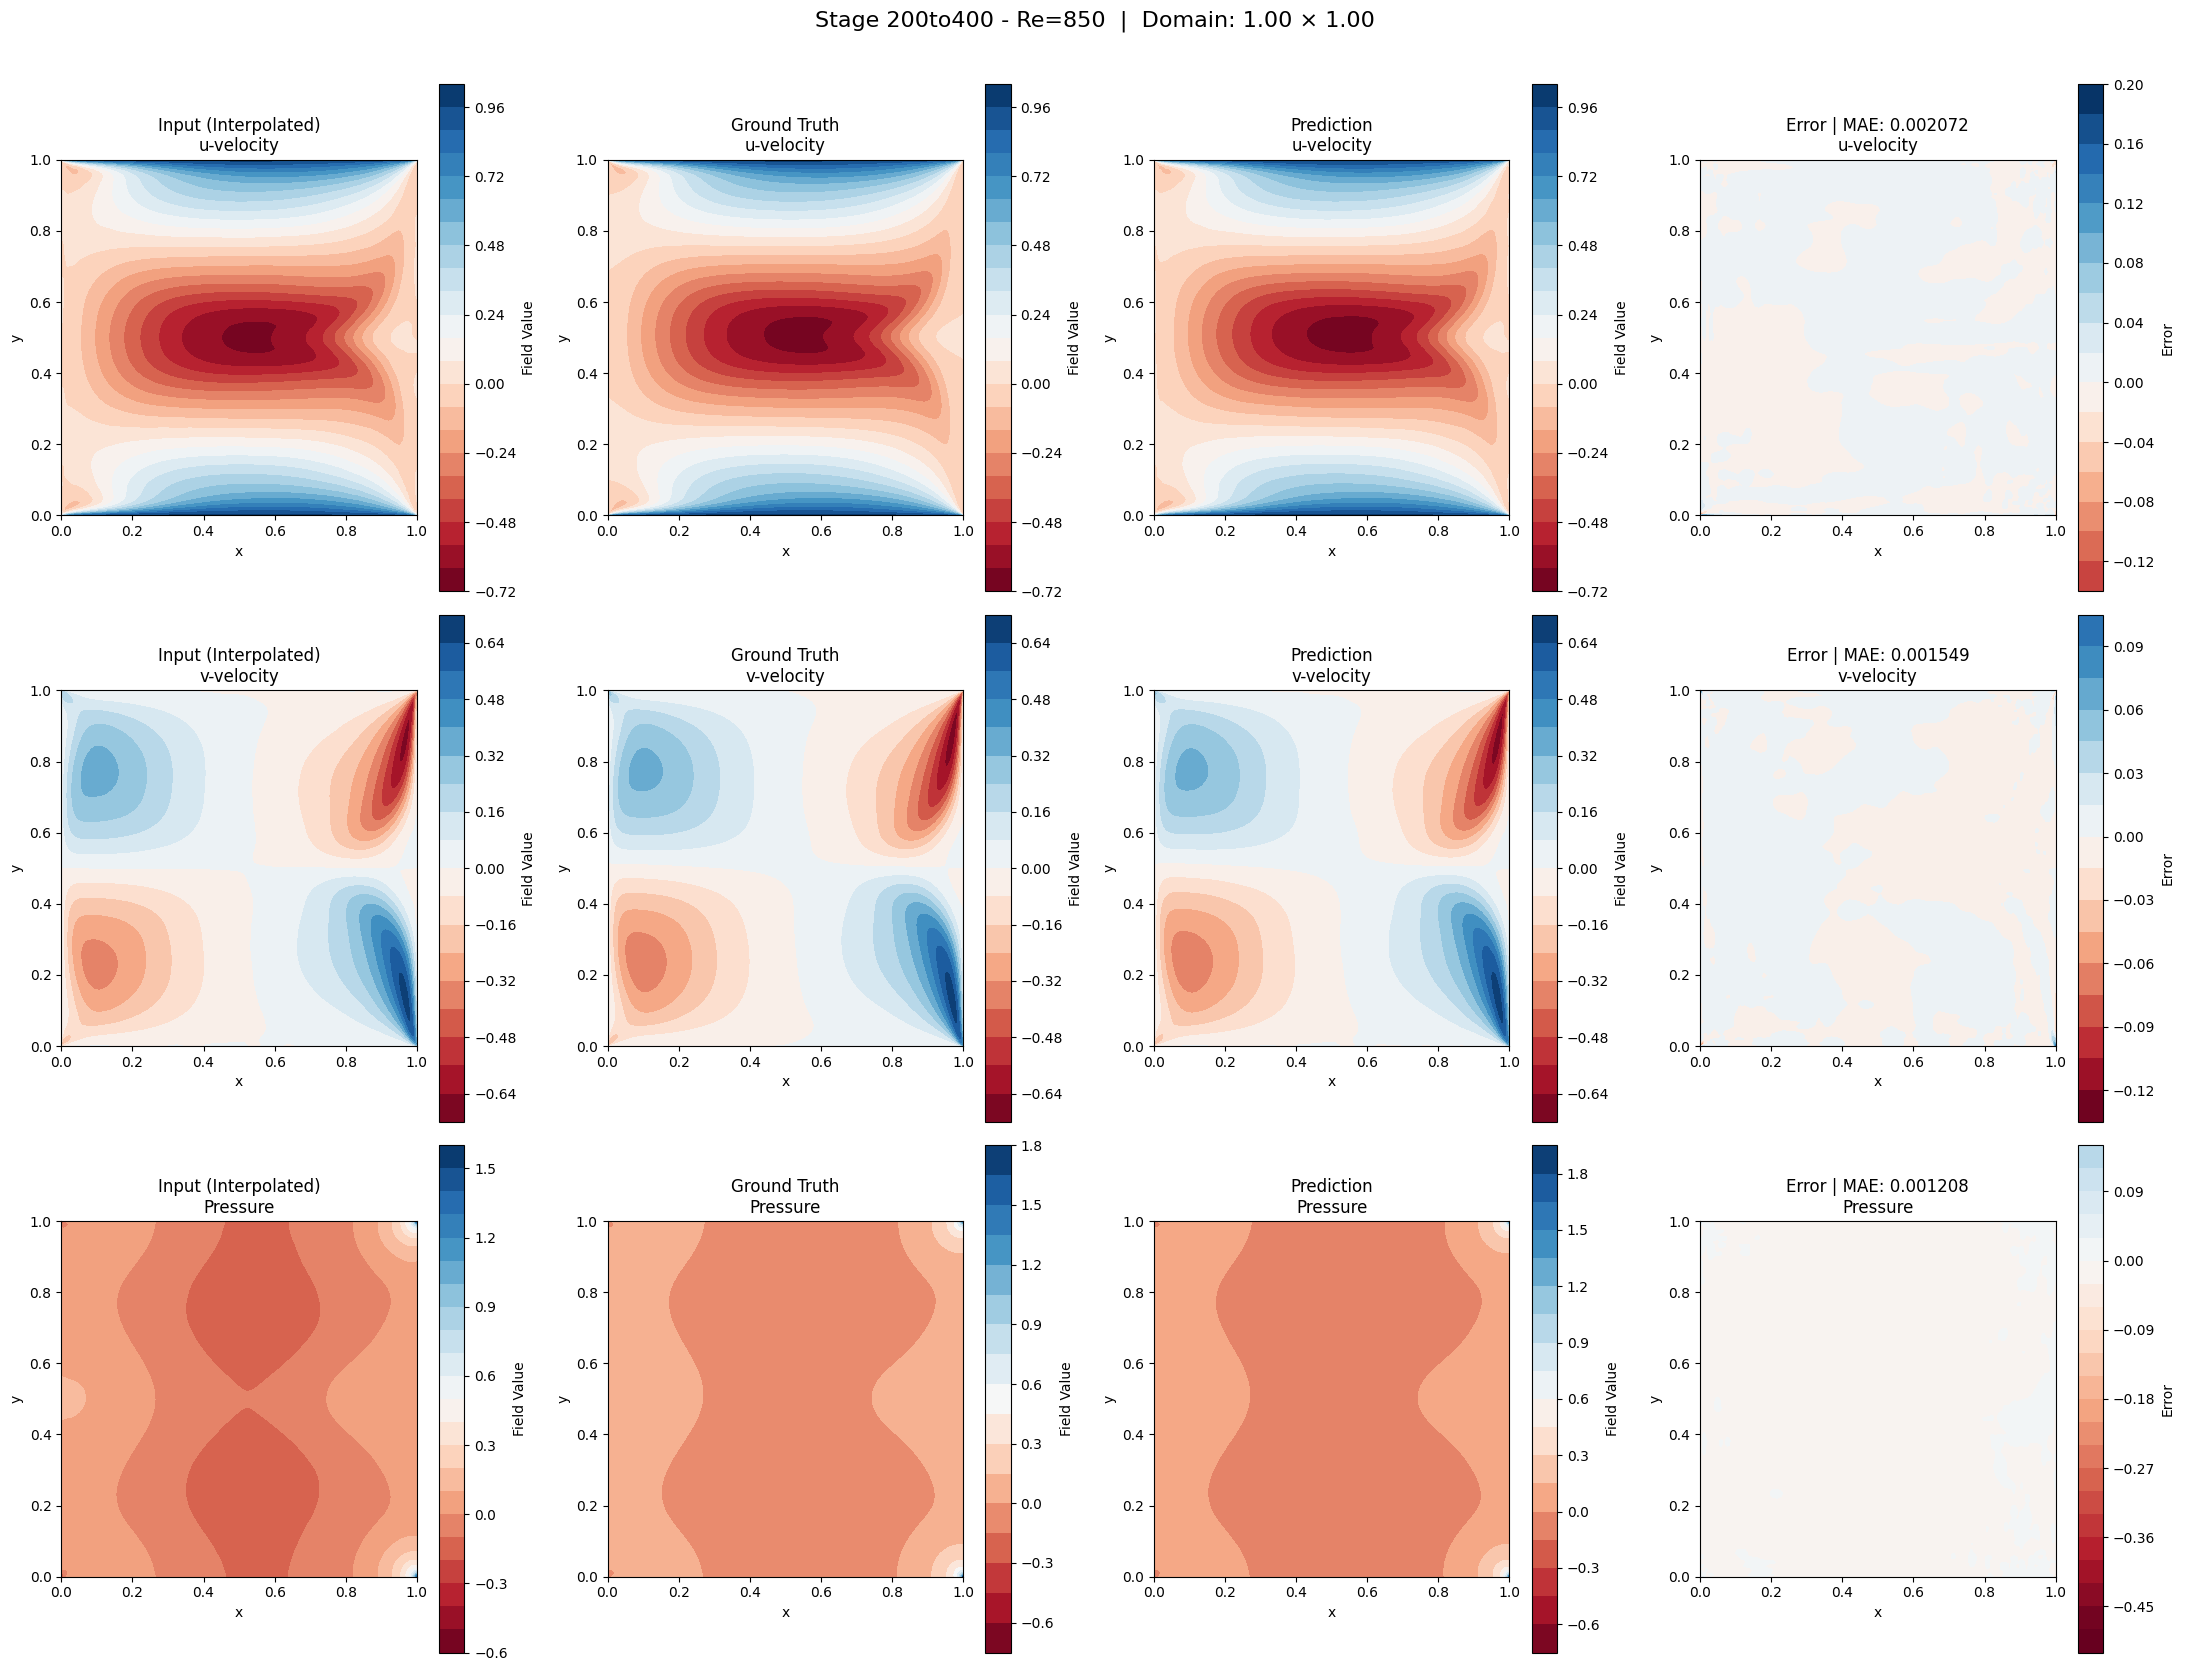


✅ ALL STAGES TRAINED SUCCESSFULLY


In [12]:
# Progressive Training Loop
print("\n" + "="*70)
print("🚀 STARTING PROGRESSIVE CASCADED TRAINING  (5-channel: [u,v,p,x̄,ȳ])")
print("="*70)

trained_models = {}
stage_metrics  = {}

for stage_idx, (target_dim, epochs) in enumerate(zip(STAGE_DIMS, EPOCHS_PER_STAGE)):
    input_dim  = LR_DIM if stage_idx == 0 else STAGE_DIMS[stage_idx - 1]
    stage_name = f"{input_dim}to{target_dim}"
    
    # ── Build geometry-aware U-Net (5-ch input → 3-ch output) ────────────────
    unet = build_residual_unet(
        input_shape=(target_dim, target_dim, 5),  # 5 = 3 flow + 2 coord channels
        base_filters=BASE_FILTERS,
        depth=UNET_DEPTH,
        activation=ACTIVATION
    )
    stage_model = InterpolateRefineModel(
        unet_model=unet,
        target_size=(target_dim, target_dim),
        name=f"stage_{stage_name}"
    )
    
    # ── Prepare 5-channel input ───────────────────────────────────────────────
    if stage_idx == 0:
        # First stage: LR ground-truth flow + LR coord channels
        x_train_input = train_data_5ch[input_dim]
        x_test_input  = test_data_5ch[input_dim]
    else:
        # Later stages: previous stage output (3-ch flow) + coord channels
        # at the current INPUT dimension.
        prev_model = trained_models[STAGE_DIMS[stage_idx - 1]]

        x_train_flow = prev_model.predict(x_train_input_prev, verbose=0)
        x_test_flow  = prev_model.predict(x_test_input_prev,  verbose=0)

        x_train_input = np.concatenate([x_train_flow, train_coords[input_dim]], axis=-1)
        x_test_input  = np.concatenate([x_test_flow,  test_coords[input_dim]],  axis=-1)
        print(f"   📊 Reattached coord channels → 5-ch input: {x_train_input.shape}")
    
    # Targets are 3-channel (flow fields only — coord channels are NOT predicted)
    x_train_target = train_data_norm[target_dim]
    x_test_target  = test_data_norm[target_dim]
    
    # Save 5-ch inputs for next stage's chaining step
    x_train_input_prev = x_train_input
    x_test_input_prev  = x_test_input
    
    # ── Train ─────────────────────────────────────────────────────────────────
    train_stage(
        model=stage_model,
        x_input=x_train_input,
        x_target=x_train_target,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        loss_config=LOSS_CONFIG,
        stage_name=stage_name
    )
    
    # ── Evaluate ──────────────────────────────────────────────────────────────
    metrics = evaluate_stage(
        model=stage_model,
        x_input=x_test_input,
        x_target=x_test_target,
        stats=test_norm_stats,
        stage_name=stage_name
    )
    
    trained_models[target_dim] = stage_model
    stage_metrics[stage_name]  = metrics
    
    stage_model.unet.save(f"unet_stage_{stage_name}_{OTHER_DETAILS}.h5")
    print(f"\n💾 Saved U-Net for stage {stage_name}")
    
    # ── Plot ──────────────────────────────────────────────────────────────────
    if PLOT_SAMPLES:
        pred_test = stage_model.predict(x_test_input, verbose=0)  # 3-ch predictions
        # Determine which sample indices to plot
        n_test = len(test_reynolds)
        plot_indices = range(n_test) if PLOT_SAMPLE_IDX is None else [PLOT_SAMPLE_IDX]
        for idx in plot_indices:
            plot_lx = float(test_lx[target_dim][idx]) if n_test > idx else 1.0
            plot_ly = float(test_ly[target_dim][idx]) if n_test > idx else 1.0
            plot_comparison(
                input_lr=x_test_input,
                target_hr=x_test_target,
                pred_hr=pred_test,
                sample_idx=idx,
                stage_name=stage_name,
                stats=test_norm_stats,
                reynolds_num=test_reynolds[idx] if n_test > idx else None,
                lx=plot_lx,
                ly=plot_ly,
            )

print("\n" + "="*70)
print("✅ ALL STAGES TRAINED SUCCESSFULLY")
print("="*70)



📊 FINAL EVALUATION: Full Pipeline (10×10  to  400×400)

🎯 Final Test Set Performance:
   MAE (u-velocity): 0.002484
   MAE (v-velocity): 0.002173
   MAE (pressure):   0.001058
   MAE (average):    0.001905


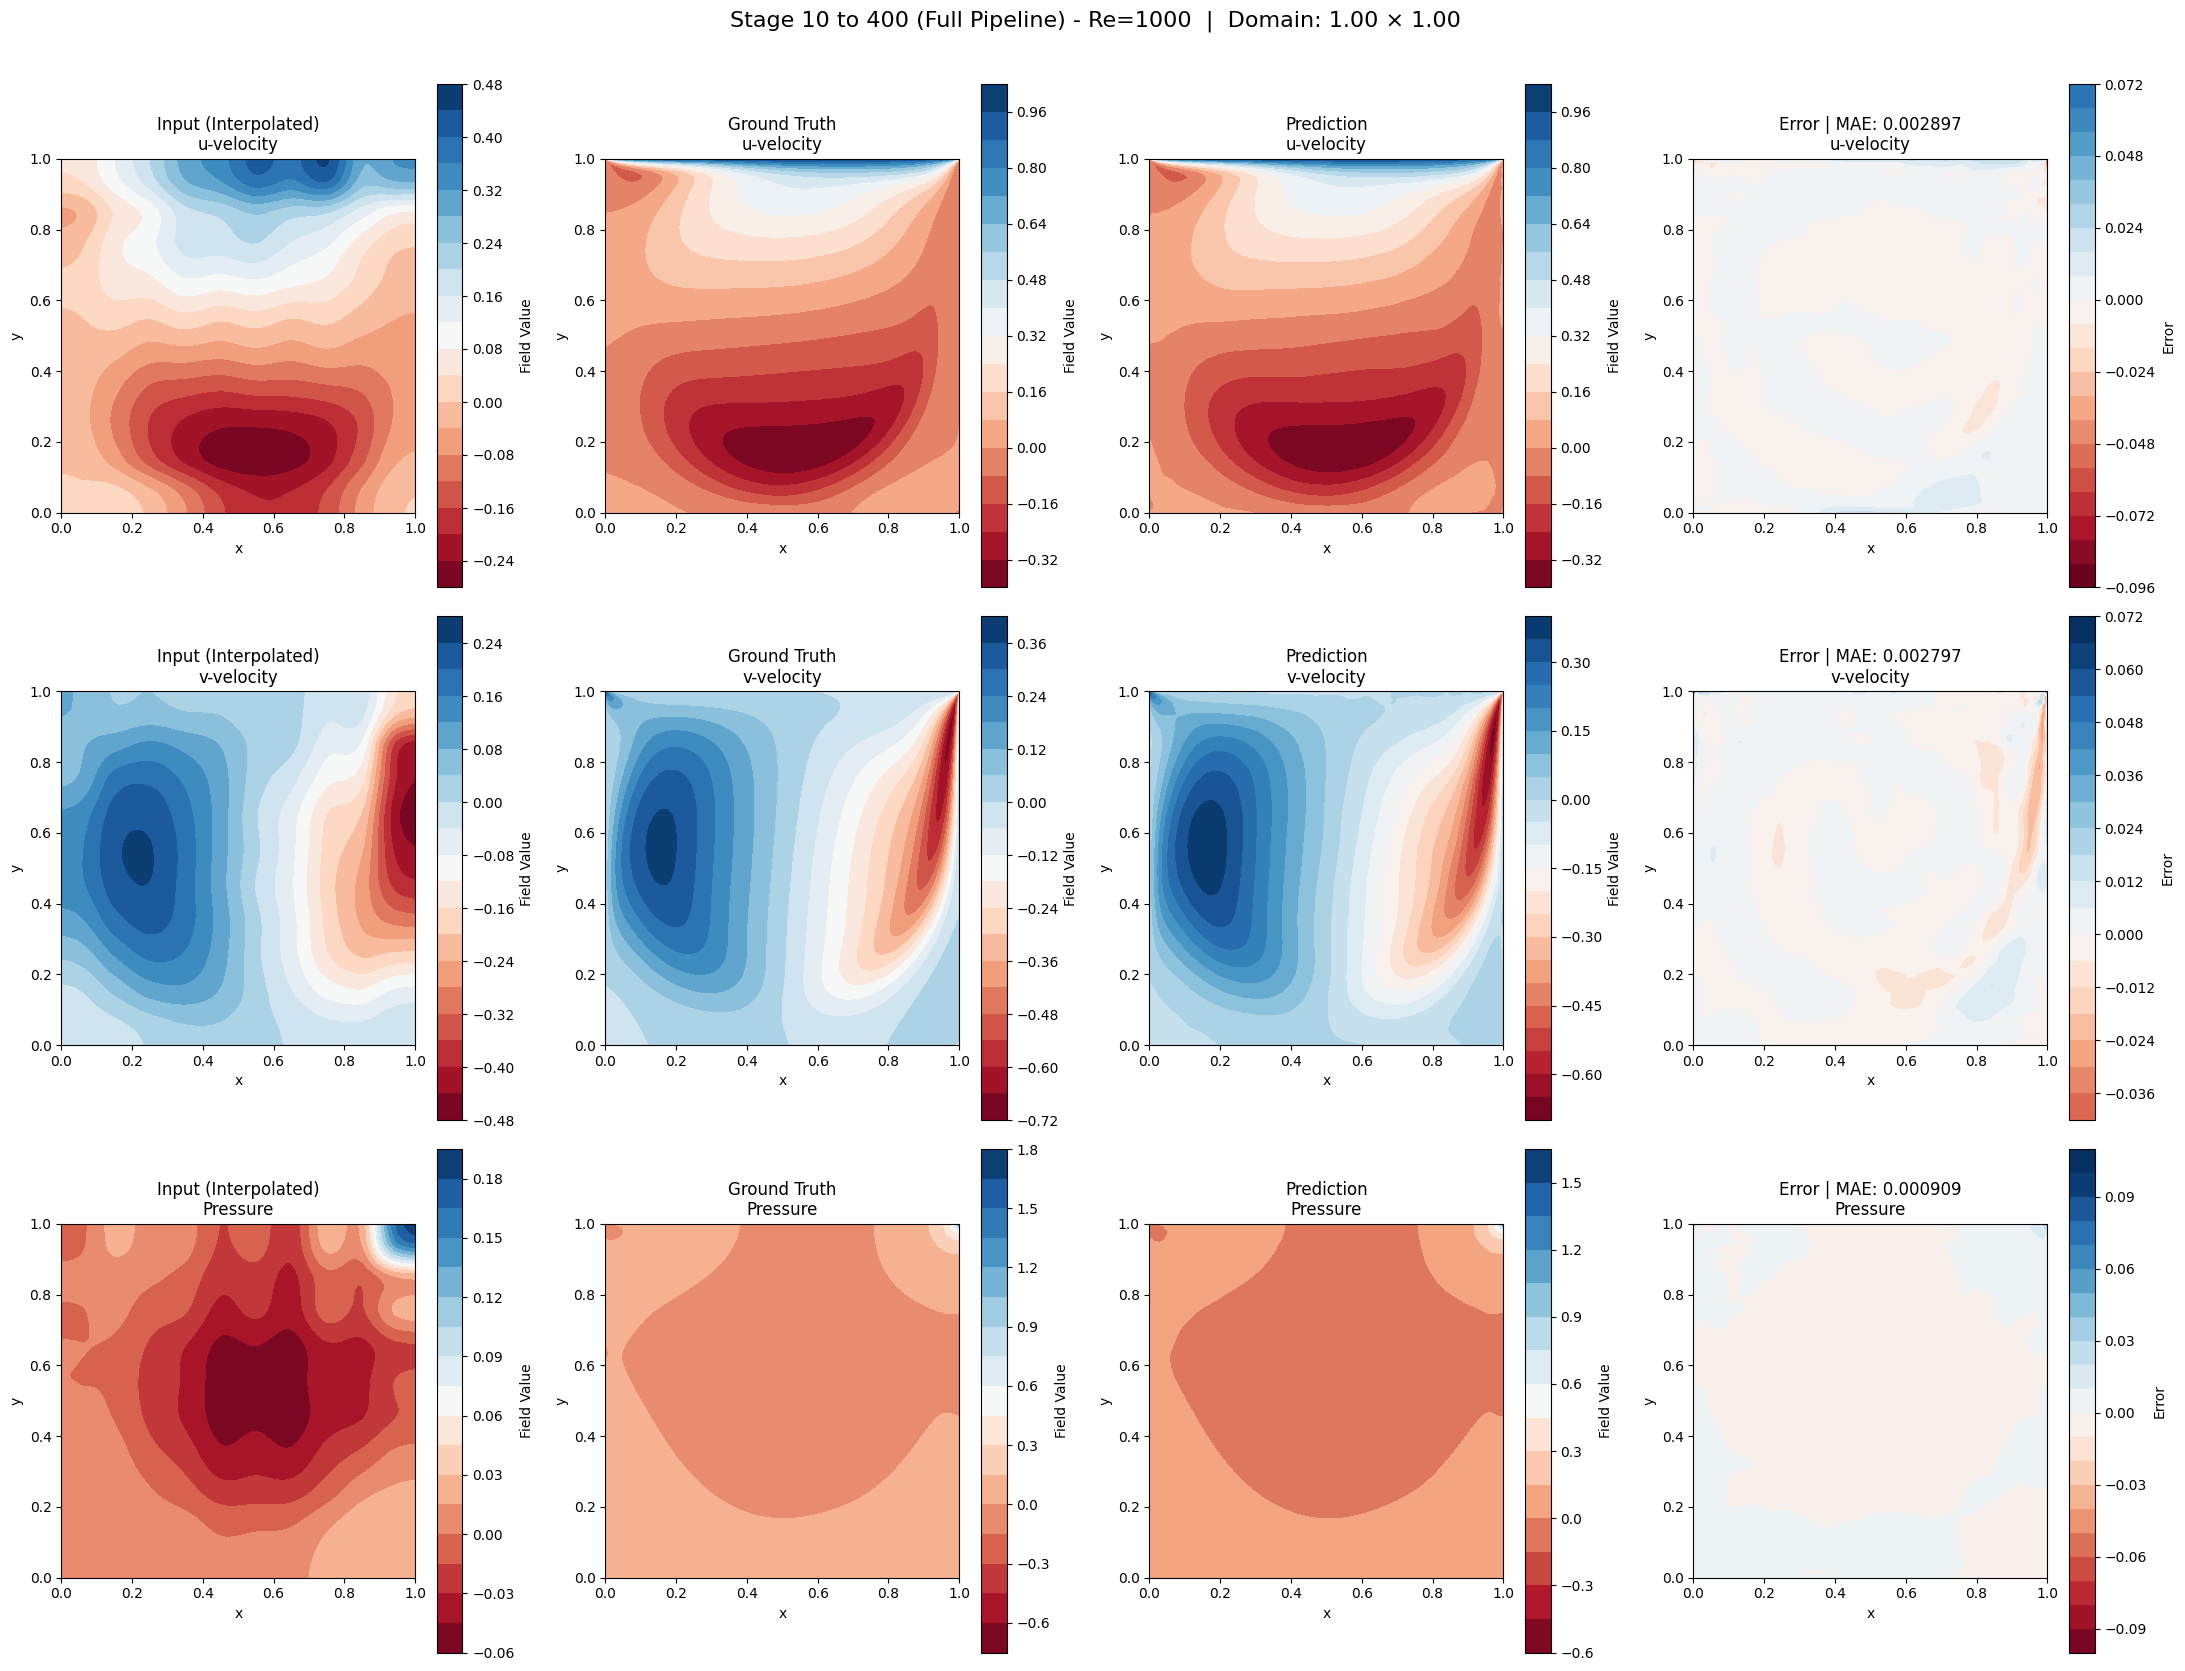

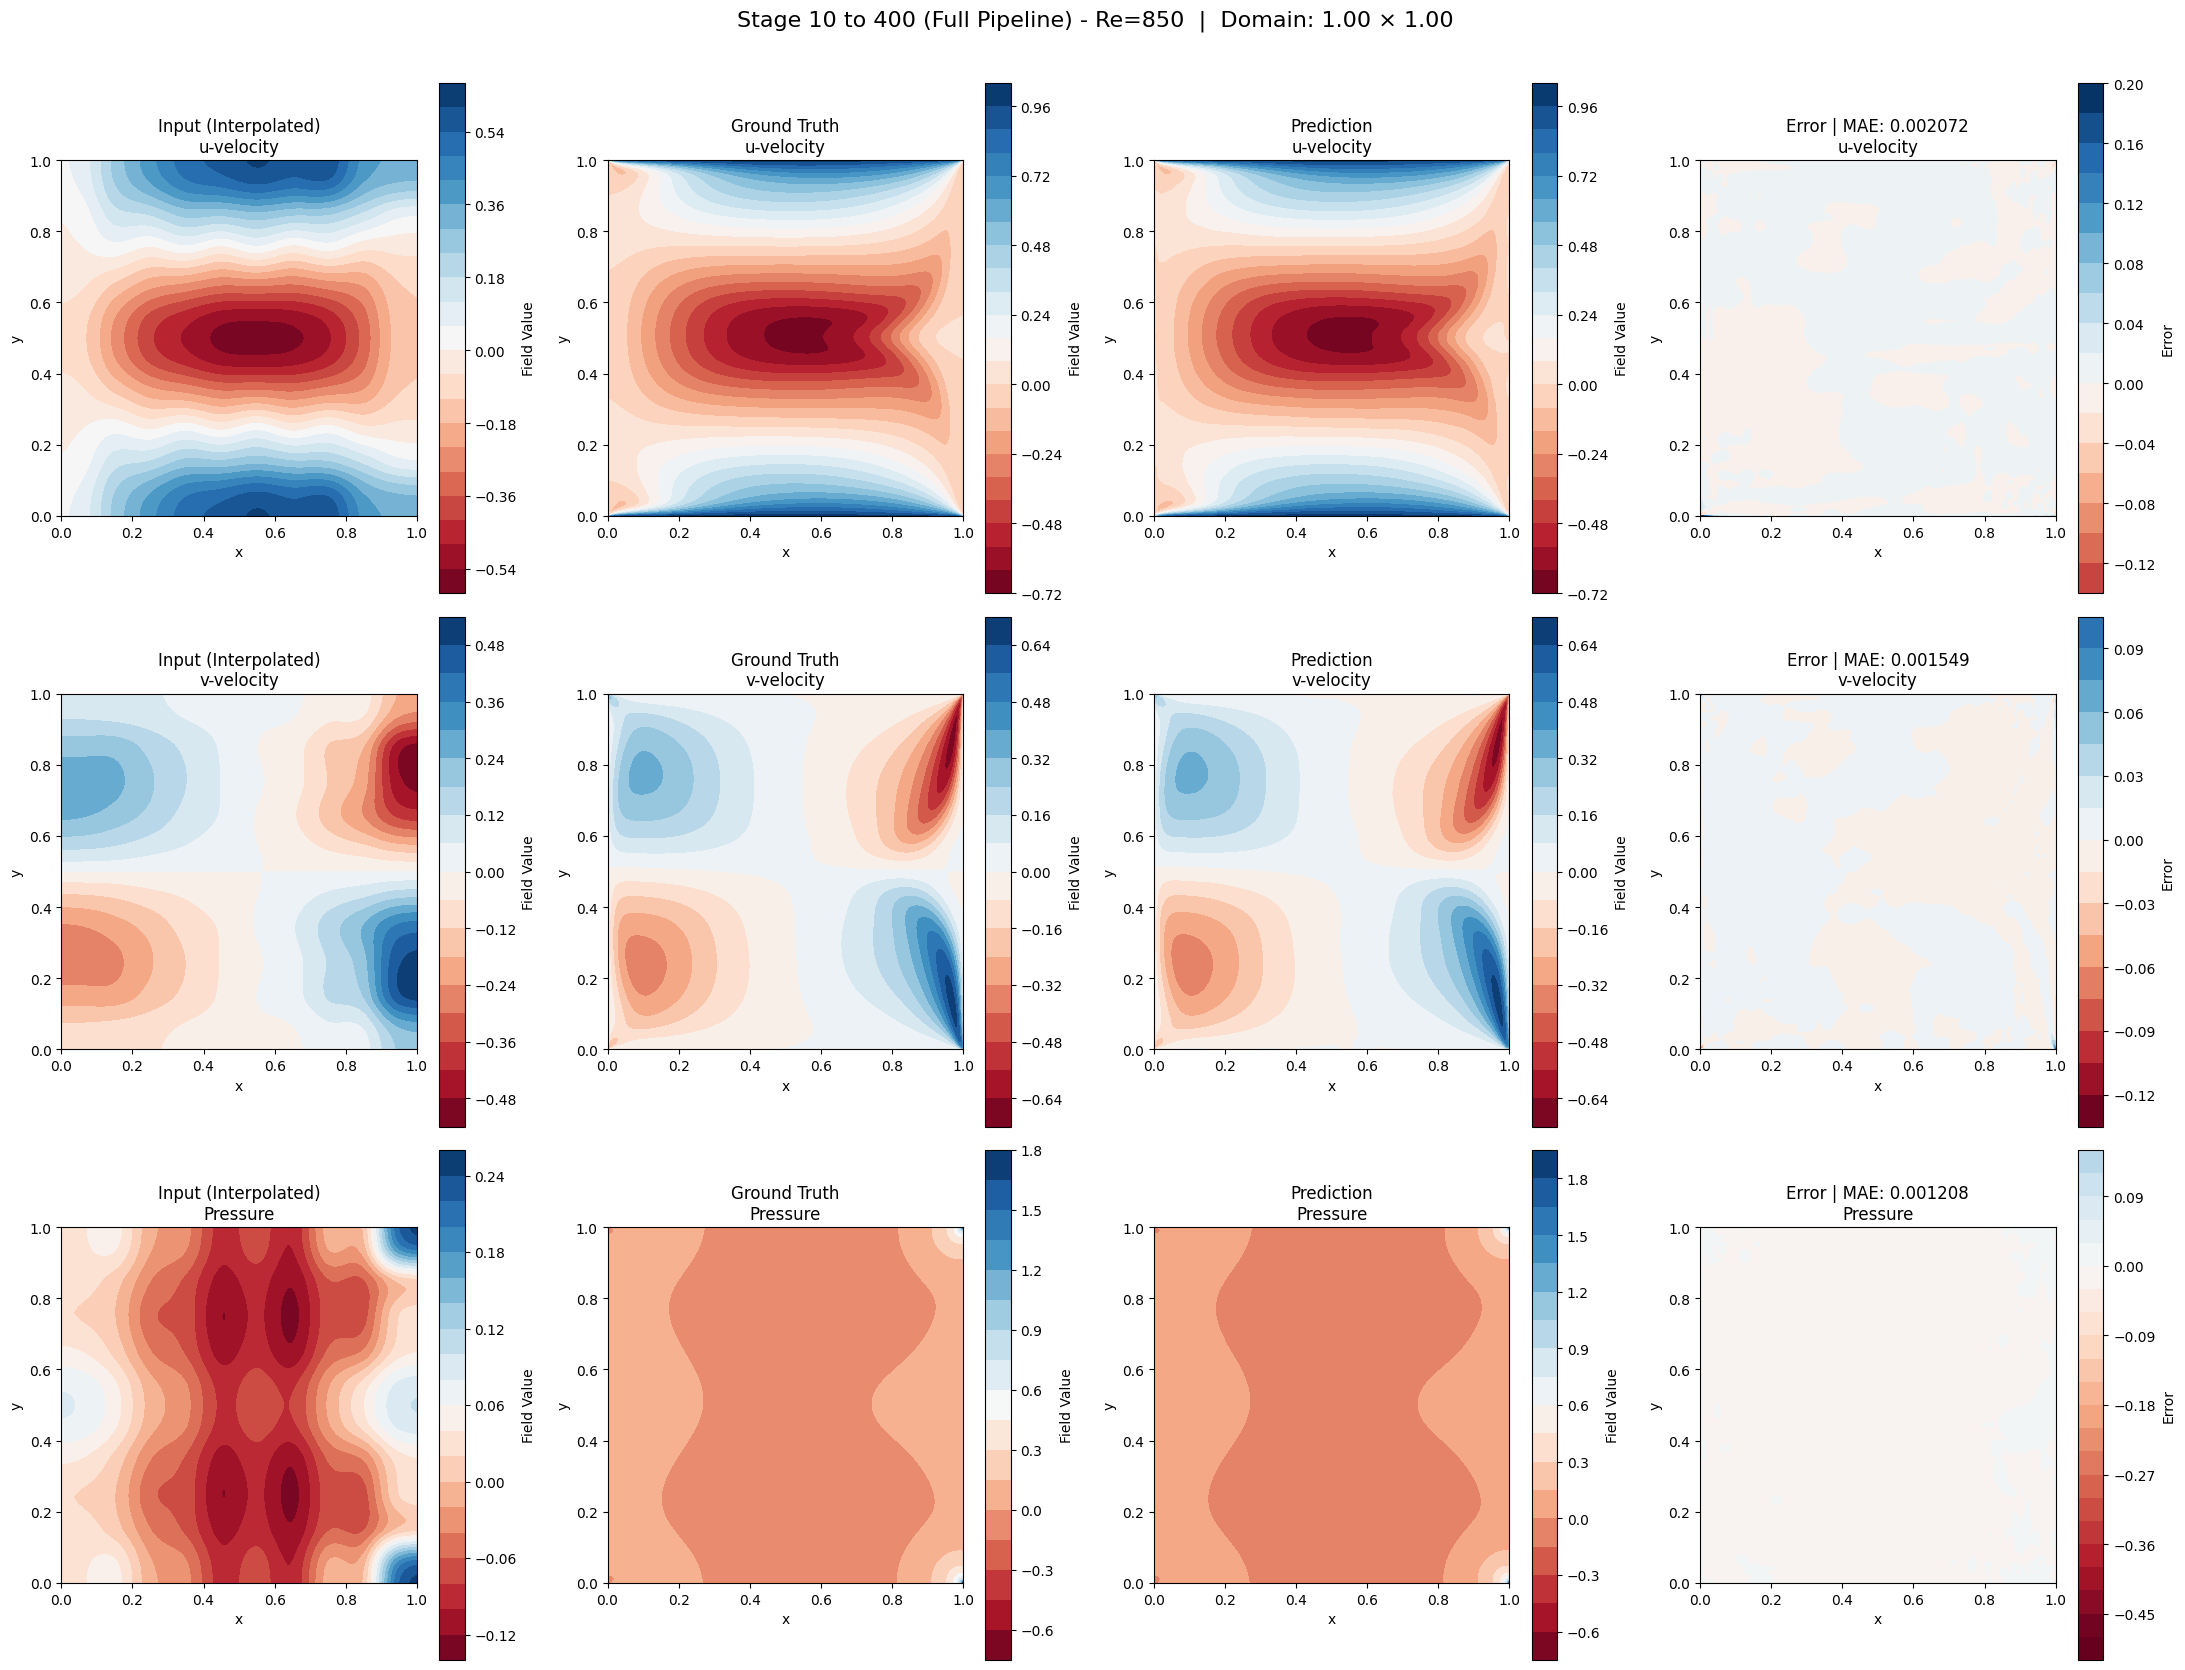

In [13]:
# Final Evaluation: Full Pipeline (10 -> 400)
print("\n" + "="*70)
print("📊 FINAL EVALUATION: Full Pipeline (10×10  to  400×400)")
print("="*70)

# Run full cascade on test data
x_current = test_data_5ch[LR_DIM]   # 5-ch

for i, target_dim in enumerate(STAGE_DIMS):
    flow_output = trained_models[target_dim].predict(x_current, verbose=0)  # 3-ch
    if i < len(STAGE_DIMS) - 1:
        x_current = np.concatenate([flow_output, test_coords[target_dim]], axis=-1)
    else:
        x_current = flow_output  # final 3-ch output

final_pred_norm   = x_current
final_target_norm = test_data_norm[400]

# Denormalize using per-sample stats
final_pred_real   = denormalize_per_sample(final_pred_norm,   test_norm_stats)
final_target_real = denormalize_per_sample(final_target_norm, test_norm_stats)

mae_u = np.mean(np.abs(final_target_real[..., 0] - final_pred_real[..., 0]))
mae_v = np.mean(np.abs(final_target_real[..., 1] - final_pred_real[..., 1]))
mae_p = np.mean(np.abs(final_target_real[..., 2] - final_pred_real[..., 2]))
mae_total = np.mean([mae_u, mae_v, mae_p])

print(f"\n🎯 Final Test Set Performance:")
print(f"   MAE (u-velocity): {mae_u:.6f}")
print(f"   MAE (v-velocity): {mae_v:.6f}")
print(f"   MAE (pressure):   {mae_p:.6f}")
print(f"   MAE (average):    {mae_total:.6f}")

# Plot final comparison — all test samples or a single one
if PLOT_SAMPLES:
    n_test = len(test_reynolds)
    plot_indices = range(n_test) if PLOT_SAMPLE_IDX is None else [PLOT_SAMPLE_IDX]
    for idx in plot_indices:
        final_lx = float(test_lx[STAGE_DIMS[-1]][idx]) if n_test > idx else 1.0
        final_ly = float(test_ly[STAGE_DIMS[-1]][idx]) if n_test > idx else 1.0
        plot_comparison(
            input_lr=test_data_5ch[LR_DIM],
            target_hr=final_target_norm,
            pred_hr=final_pred_norm,
            sample_idx=idx,
            stage_name="10 to 400 (Full Pipeline)",
            stats=test_norm_stats,
            reynolds_num=test_reynolds[idx] if n_test > idx else None,
            lx=final_lx,
            ly=final_ly,
        )


In [14]:
# Save metrics summary
print("\n💾 Saving metrics summary...")
with open(f"metrics_summary_{LR_DIM}to{STAGE_DIMS[-1]}_{OTHER_DETAILS}.txt", 'w') as f:
    f.write("# Progressive Cascaded Super-Resolution Metrics\n")
    f.write("# Normalization: per-sample Z-score (no global stats file needed)\n")
    f.write("# Stage-wise performance\n\n")
    for stage_name, metrics in stage_metrics.items():
        f.write(f"Stage: {stage_name}\n")
        f.write(f"  MAE (u): {metrics['mae_u']:.6f}\n")
        f.write(f"  MAE (v): {metrics['mae_v']:.6f}\n")
        f.write(f"  MAE (p): {metrics['mae_p']:.6f}\n")
        f.write(f"  MAE (avg): {metrics['mae_avg']:.6f}\n\n")
    
    f.write(f"\nFinal Pipeline Performance (10 to {STAGE_DIMS[-1]}x{STAGE_DIMS[-1]}):\n")
    f.write(f"  MAE (u): {mae_u:.6f}\n")
    f.write(f"  MAE (v): {mae_v:.6f}\n")
    f.write(f"  MAE (p): {mae_p:.6f}\n")
    f.write(f"  MAE (avg): {mae_total:.6f}\n")

print("\n✅ All artifacts saved.")
print(f"\n{'='*70}")
print("🎉 TRAINING COMPLETE!")
print(f"{'='*70}")



💾 Saving metrics summary...

✅ All artifacts saved.

🎉 TRAINING COMPLETE!
